In [1]:
''' 
Using an external trigger, compare time between successive packet timestamps. Inconsistencies suggest drifting chip clocks. 

    - Too few ticks: chip occasionally fails to register the clock pulse 
    - Too many ticks: noise on clock line 
    - Variation between too few and too many ticks, with constant mean: slewing/jitter of the clock or ext_trig pulse
'''

import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm
import io
import tarfile
import os
import math

from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev
from pathlib import Path
from datetime import datetime
from scipy import stats

##########################################################
# Initialize parameters  
##########################################################

# set1-7 datafiles. This file should be run after disabling hot channels, because sometimes hot channels
# impact pedestal values
#filename = "../data/packet-warm_timing_120s_7tiles_2026_1_13.hdf5"
#filename = "../data/packet-warm_timing_120s_7tiles_2026_1_13.hdf5"
#filename = "../data/packet-warm_timing_300ns_120s_7tiles_2026_1_13.hdf5"
filename = "../data/packet-warm_timing_200ns_120s_7tiles_2026_1_15.hdf5"
#filename = "../data/packet-warm_timing_200ns_120s_7tiles_2026_1_19.hdf5"
#filename = "../data/packet-warm_timing_150cycles_600s_7tiles_2026_1_21.hdf5"
#filename = "../data/packet-warm_timing_150cycles_600s_7tiles_2026_1_21_10_40.hdf5"
#filename = "../data/test-warm_timing_exclude_duplicates.hdf5"
#filename = "../data/packet-warm_test_enable_reset.hdf5"

# tiles tested in this filename or the subset of tiles on which you wish to check tally 
tiles = [1,2,3,4,5,6,7]

# serial numbers for set 1-7
chip_serial_number_list = ['', '4k02056', '4k03591', '4k01892', '4k02219', '4k02371', '4k04834', '4k00101' ]
ntiles = 7

# provide more detailed information for a particular tile
verbose_tile = 2
verbose_chip = 19

# initialize
first_tile = True
percent_low_list, percent_high_list, tile_list = [], [], []
highest_timestamp = 2**28

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp')


In [2]:
def get_io_channels(tile):

    # each tile has up to 4 io_channels that uniquely identify the tile within an io_group
    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20],
        [21,22,23,24],
        [25,26,27,28],
        [29,30,31,32],
        [33,34,35,36],
        [37,38,39,40]
        ]
    
    return io_ch_per_tile[tile]


In [3]:
def analyze_duplicate_pkts(tile, chip, pkt1, pkt2, pkt_numb):

    global n_diff_channel, n_diff_word, n_diff_trigtype, n_diff_rec_ts, duplicate_words1, duplicate_words2, total_n_duplicates
    global verbose_tile, duplicate_receipt_ts, diff_rec_ts

    pkt_keys = ['io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
                'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
                'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp']

    # check every packet attribute to see if it is duplicated
    for key in pkt_keys:
        pkt1_key = pkt1[key]
        pkt2_key = pkt2[key]

        # do not print out a message if the attribute is receipt timestamp, as this is expected to be different
        if pkt1_key != pkt2_key and tile == verbose_tile and key != 'receipt_timestamp':
            print(f"Tile {tile}, Chip {chip} pkt # {pkt_numb} had unique {key} values [ {pkt1_key}, {pkt2_key} ]")
    
    channel1   = pkt1['channel_id']
    dataword1  = pkt1['dataword']
    trig_type1 = pkt1['trigger_type']
    rec_ts1    = pkt1['receipt_timestamp']
    ts1        = pkt1['timestamp']

    channel2   = pkt2['channel_id']
    dataword2  = pkt2['dataword']
    trig_type2 = pkt2['trigger_type'] 
    rec_ts2    = pkt2['receipt_timestamp']  
    ts2        = pkt2['timestamp']
    
    duplicate_words1.append(dataword1)
    duplicate_words2.append(dataword2)    
    
    # count how many times a duplicate timestamp packet has different channel_ids, datawords, and trigger types
    if channel1   != channel2:
        n_diff_channel  +=1

    if dataword1  != dataword2:
        n_diff_word     +=1

    if trig_type1 != trig_type2:
        n_diff_trigtype +=1

    if rec_ts1    != rec_ts2:
        n_diff_rec_ts  +=1
        diff_rec_ts[chip].append(rec_ts2-rec_ts1)
        if chip == verbose_chip and tile == verbose_tile:
            print(f"Chip {tile}-{chip} Receipt ts for duplicate pkts [{rec_ts1}, {rec_ts2}]")
                
    else:
        duplicate_receipt_ts[chip] +=1
        print(f"Tile {tile}, Chip {chip} pkt # {pkt_numb} had a duplicate pair with the same receipt timestamps [ {rec_ts1}, {rec_ts2} ] and same timestamps [ {ts1}, {ts2} ]")
    
    total_n_duplicates += 1
    
    return

In [4]:
def get_timestamps(filename, tile, chip_serial_number):
    
    global pedestals, percent_low_list, percent_high_list, tile_list, verbose_tile, first_tile, total_n_duplicates
    global n_diff_channel, n_diff_word, n_diff_trigtype, n_diff_rec_ts, duplicate_words1, duplicate_words2
    global duplicate_receipt_ts, diff_rec_ts
    
    # initialize variables tracked at the tile level
    verbose = False
    slope_list, intercept_list, r_sqr_list, first_t, good_chip_list, all_chip_list = [],[],[], [], [], []
    npkts_list, nchips = [], 0
    n_missing_list, n_duplicates_list, n_skipped_ts_list = [], [], []
    first_good_chip, first_bad_chip, total_n_duplicates = 0, 0, 0
    n_diff_channel, n_diff_word, n_diff_trigtype, n_diff_rec_ts = 0,0,0,0
    duplicate_words1, duplicate_words2 = [], []
    duplicate_receipt_ts = [0 for chp in range(256)]
    diff_rec_ts = [[] for chp in range(256)]
    unique_receipt_ts_list = []
    
    # read packet data from initialized file name
    f = h5py.File(filename, 'r')
    packets = f['packets'][:]
    
    # create arrays of data packets
    data_mask     = f['packets'][:]['packet_type']  == 1
    data_pkts     = packets[data_mask]
    ts            = data_pkts['timestamp'][:]

    if first_tile:
        print(f"\tHighest Timestamp in datafile = {max(ts)}")
        first_tile = False
    
    # identify io_channels with data packets in this data file
    unique_io_channels = list(dict.fromkeys(data_pkts['io_channel'][:]))
    unique_io_channels = sorted(unique_io_channels)

    # print out run statistics for the file
    unixtime = f['packets'][:]['timestamp'][f['packets'][:]['packet_type'] == 4]
    livetime = np.max(unixtime)-np.min(unixtime)        
    npkts    = len(data_pkts) 
    
    print(f"\t{npkts:,} data packets for tile {tile} arriving at an average rate of {npkts/livetime:.0f} pkts/s over {livetime}s of data taking")         
    
    # get a list of the io_channels that could be enabled for a given tile, and then determine which
    # ones were enabled
    io_channel_ids = get_io_channels(tile)
    enabled_io_channels = list(set(io_channel_ids) & set(unique_io_channels))
    
    # mask for the chosen tile
    tile_mask = (data_pkts['io_channel']== io_channel_ids[0]) | (data_pkts['io_channel']== io_channel_ids[1]) | (data_pkts['io_channel']== io_channel_ids[2]) | (data_pkts['io_channel']== io_channel_ids[3])
    data_pkts = data_pkts[tile_mask]
    
    # check for tiles with no data    
    if len(data_pkts) ==0: 
        print(f'There are no data packets for tile {tile}')        
        return 
    else:
        print(f"\tEnabled io_channels for tile {tile}: {enabled_io_channels}")

    tile_list.append(tile)

    # count invalid packets
    invalid_count = data_pkts['valid_parity'][:].tolist().count(0)
    invalid_percent = 100 * invalid_count / len(data_pkts)
    print(f"\t{invalid_count} packets (or {invalid_percent}%) had Invalid Parity")

    # graph receipt timestamps for the tile
    rec_ts = data_pkts['receipt_timestamp']

    fig, ax = plt.subplots(1,2, figsize=(12, 3))
    ax[0].plot(rec_ts)
    ax[0].set_title(f"Receipt Timestamps for Tile {tile}\nBenchtop test v3a Tile #{tile} ({chip_serial_number})")
    ax[0].set_xlabel(f'Packet')
    ax[0].set_ylabel(f'Receipt Timestamps')    

    ax[1].hist(rec_ts, bins=1000)
    ax[1].set_title(f"Receipt Timestamps for Tile {tile}\nBenchtop test v3a Tile #{tile} ({chip_serial_number})")
    ax[1].set_xlabel(f'Receipt Timestamps')
    ax[1].set_ylabel(f'Packet Count')        

    plt.show 
    
    # count the # of pkts in each chip
    for chip in range(11, 171):

        '''
        if the clock (and receipt of an external trigger) were perfect there would be exactly 120 pkts
        for a datafile of 120s with an external trigger of 1Hz
        '''        
        # mask for channel 0 on each chip
        chip_mask = data_pkts['chip_id'] == chip
        chip_pkts = data_pkts[chip_mask]  
        chan_mask = chip_pkts['channel_id'] == 0
        chan_pkts = chip_pkts[chan_mask]
        chan_ts   = chan_pkts['timestamp'][:]
        
        npkts = len(chan_pkts)
        npkts_list.append(npkts)

        nchips+=1
              
    '''
    Fewer pkts than expected may indicate all external triggers were not received. More pkts 
    than expected may indicate the external trigger line is noisy on that chip
    '''
    
    mode_npkts = mode(npkts_list)

    print(f"\tTile {tile}: most common # of pkts in a chip = {mode_npkts}")
    
    # for each tile record stats for number of pkts
    npkts_low  = sum(1 for x in npkts_list if x < mode_npkts)
    percent_low  = 100*npkts_low /nchips
    percent_low_list.append(percent_low)
    
    npkts_high = sum(1 for x in npkts_list if x > mode_npkts)    
    percent_high = 100*npkts_high /nchips
    percent_high_list.append(percent_high)
    
    npkts_mode = sum(1 for x in npkts_list if x == mode_npkts)   
    percent_mode = 100*npkts_mode/nchips
    
    print(f"\n------------ Results Tile {tile} --------------")
    
    print(f"{npkts_mode} chips (or {percent_mode:.0f}%) had {mode_npkts} pkts")
    print(f"{ npkts_low} chips (or {percent_low :.0f}%) had fewer pkts (most likely cause: FIFO admission losses, in rare cases triggers were not received)")
    print(f"{npkts_high} chips (or {percent_high:.0f}%) had more pkts (most likely because 2 pkts were generated for some triggers)\n")
    
    max_npkts = max(npkts_list)

    # histogram the number of packets for each chip's channel 0
    fig, ax = plt.subplots(1,1, figsize=(6, 3))
    ax.hist(npkts_list, color = 'g', bins = max_npkts)
    ax.set_title(f"# of Pkts in each Chip's Channel 0 (mode {mode_npkts:.0f})\nBenchtop test v3a Tile #{tile} ({chip_serial_number})")
    ax.set_yscale("log")
    ax.text(0, 11, f"{percent_mode:.0f}% of chips had {mode_npkts} pkts\n{percent_low:.0f}% had fewer pkts\n{percent_high:.0f}% had more pkts", color = "r")
    ax.set_xlabel(f'Number of Packets')
    ax.set_ylabel(f'# of Chips')
    plt.show
    
    # prepare to plot a time series of dt between packets for the 1st 4 chips with the expected # of packets
    fig, axis = plt.subplots(1,4, figsize=(20, 3))
    plt.suptitle(f'(Δt between Packets) - 1E7 for 4 chips (all with the expected # of pkts), Benchtop test v3a Tile #{tile} ({chip_serial_number})')    
    
    graphed_chips = 0
    
    # check the # of clock ticks between successive timestamps on channel 0 of each chip that had the expected # of pkts
    for chip in range(11, 171):
        
        '''
        the external trigger was only sent to channel 0 on each chip because the same clock is
        shared between all channels on a given chip. To measure the clock's skew we only need
        to test one channel
        '''

        # mask for channel 0 on the given chip
        chip_mask = data_pkts['chip_id'] == chip
        chip_pkts = data_pkts[chip_mask]  
        chan_mask = chip_pkts['channel_id'] == 0
        chan_pkts = chip_pkts[chan_mask]
        chan_ts   = chan_pkts['timestamp']
        chan_rts  = chan_pkts['receipt_timestamp']        
        
        if tile == verbose_tile and chip == verbose_chip:
            chan_rts  = chan_pkts['receipt_timestamp'][:]
            
            fig, ax = plt.subplots(1,1, figsize=(6, 3))
            ax.plot(chan_rts)
            ax.set_title(f"Receipt Timestamps for Chip {chip}\nBenchtop test v3a Tile #{tile} ({chip_serial_number})")
            #ax.set_yscale("log")
            ax.set_xlabel(f'Packet')
            ax.set_ylabel(f'Receipt Timestamps')       
            plt.show 

            fig, ax = plt.subplots(1,1, figsize=(6, 3))            
            ax.plot(chan_ts)
            ax.set_title(f"Packet Timestamps for Chip {chip}\nBenchtop test v3a Tile #{tile} ({chip_serial_number})")
            #ax.set_yscale("log")
            ax.set_xlabel(f'Packet')
            ax.set_ylabel(f'Packet Timestamps')       
            plt.show             
        
        npkts = len(chan_ts)

        # create lists for graphing
        n_missing_list.append(npkts - mode_npkts)
        all_chip_list.append(chip)
        unique_receipt_ts_list.append( len( set(chan_rts) ) )
        
        # initialize variables tracked at the chip level
        dt, pkt_list, nreset_chip, n_duplicates, n_skipped_ts = [], [], 0, 0, 0
            
        '''
        Create a list of the time difference between triggers minus 1e7 (the "idealized" difference
        for a perfect chip clock and a perfect 1Hz external trigger), but skip pkts where the clock is resetting
        '''
        
        if npkts > 2:
            for pkt in range(npkts-1):
    
                if chan_ts[pkt+1] > chan_ts[pkt]:
                    dt.append(chan_ts[pkt+1] - chan_ts[pkt] - 1E7)
                    pkt_list.append(pkt)

                    # check for skipped timestamps. (note: the "int" function rounds down)
                    if dt[-1] > 8E6:
                        n_skipped_ts += int( (chan_ts[pkt+1] - chan_ts[pkt])/1E7 )

                # count duplicate timestamps
                elif chan_ts[pkt+1] == chan_ts[pkt]:
                    n_duplicates +=1
                    analyze_duplicate_pkts(tile, chip, chan_pkts[pkt+1], chan_pkts[pkt], pkt)

                # these cases are for packets just after the clock resets from its maximum value of  
                else:
                    nreset_chip +=1

        n_duplicates_list.append(n_duplicates)
        n_skipped_ts_list.append(n_skipped_ts)

        if duplicate_receipt_ts[chip] > 0:
            print(f"\nChip {chip} had {duplicate_receipt_ts[chip]} duplicate consequtive receipt timestamps\n")

        # graph difference in receipt timestamp for chips that had duplicate packets
        if len(diff_rec_ts[chip]) > 0:

            fig, ax = plt.subplots(1,1, figsize=(6, 3))
            ax.hist(diff_rec_ts[chip], color = 'b')
            ax.set_title(f'Δt Receipt Timestamps for Duplicate Pkts on Chip {chip}\nBenchtop test v3a Tile #{tile} ({chip_serial_number})')
            ax.set_xlabel(f'Receipt_ts_i+1 - Receipt_ts_i')
            ax.set_ylabel(f'Count') 
        
        # create lists of variables that relate to packet timing on chips with the expected # of packets
        if npkts == mode_npkts:

            if first_good_chip ==0:
                first_good_chip = chip
                good_chip_ts  = chan_ts
                good_chip_rts = chan_rts
            
            nreset_expected = nreset_chip
            
            # fit a line through the dt values and record regression variables
            slope, intercept, r_value, p_value, std_err = stats.linregress(pkt_list, dt)
    
            # create lists of various timing attributes
            slope_list.append(slope)
            intercept_list.append(intercept)
            r_sqr_list.append(r_value)
            first_t.append(chan_pkts[0])
            good_chip_list.append(int(chip))   
            
            # graph time series of Δt for 4 chips with the expected # of packets
            if graphed_chips < 4:
        
                slope, intercept, r_value, p_value, std_err = stats.linregress(pkt_list, dt)
        
                y_fit = np.array(pkt_list, dtype=float) * slope            

                min_dt = min(dt)
                
                # graph time series of differences between successive timestamps
                axis[graphed_chips].plot(pkt_list, dt, color = 'g')
                axis[graphed_chips].plot(pkt_list, y_fit + intercept, color='orange', label=f'Line (slope={slope:.2f})')
                axis[graphed_chips].set_xlabel(f'Packet Number')
                axis[graphed_chips].text(40, min_dt, f"R-squared: {r_value**2:.2f}\nSlope: {slope:.2f}", color = 'orange')
                if graphed_chips==0:
                    axis[graphed_chips].set_ylabel(f'Timestamp_i+1 - Timestamp_i')

                graphed_chips +=1

                if graphed_chips == 3:
                    plt.show

                    fig, ax = plt.subplots(1,1, figsize=(6, 3))
                    ax.hist(dt, color = 'g')
                    ax.set_title(f"Δt between Packets) - 1E7: Chip {chip} has expected # pkts ({mode_npkts})\nBenchtop test v3a Tile #{tile} ({chip_serial_number})")
                    ax.set_yscale("log")
                    ax.set_xlabel(f'timestamp_i+1 - timestamp_i')
                    ax.set_ylabel(f'# of pkts')
                    plt.show

        # randomly choose 1 bad chip to print more detailed information for chips without the expected # of packets
        else:
            
            if n_duplicates ==0:
                print(f"Chip {chip} had {npkts} packets")
            else:
                print(f"Chip {chip} had {npkts-n_duplicates} unique pkts and {n_duplicates} with duplicate timestamps")
        
            # store information to later create a histogram of dt for 1 chip with too many packets
            if npkts > mode_npkts and first_bad_chip==0:    

                first_bad_chip = chip 
                bad_chip_ts = chan_ts
                bad_chip_rts = chan_rts
                bad_chip_npkts = npkts
                bad_chip_unique = npkts - n_duplicates
    
    # graph timestamp and receipt_timestamp series for 1 good chip
    fig, ax = plt.subplots(1,2, figsize=(20, 3))
    ax[0].plot(good_chip_ts, color = 'm')
    ax[0].set_title(f'Typical Pattern of Timestamps (Chip {first_good_chip})\nBenchtop test v3a Tile #{tile} ({chip_serial_number})')
    ax[0].set_xlabel(f'Packet #')
    ax[0].set_ylabel(f'Timestamps')    
    
    ax[1].plot(good_chip_rts, color = 'r')
    ax[1].set_title(f'Typical Pattern of Receipt Timestamps (Chip {first_good_chip})\nBenchtop test v3a Tile #{tile} ({chip_serial_number})')
    ax[1].set_xlabel(f'Packet #')
    ax[1].set_ylabel(f'Receipt Timestamps')    

    # graph timestamp and receipt_timestamp series for 1 bad chip
    fig, ax = plt.subplots(1,2, figsize=(20, 3))

    ax[0].plot(bad_chip_ts, color = 'm')
    ax[0].set_title(f"Atypical Pattern of Timestamps ({mode_npkts} pkts are expected)\nChip {first_bad_chip} has {bad_chip_npkts} pkts, but only {bad_chip_unique} are unique\nBenchtop test v3a Tile #{tile} ({chip_serial_number})")
    ax[0].set_xlabel(f'Packet #')
    ax[0].set_ylabel(f'Timestamps')
    plt.show 

    ax[1].plot(bad_chip_rts[0:10], color = 'm')
    ax[1].set_title(f"Atypical Pattern of Receipt Timestamps ({mode_npkts} pkts are expected)\nChip {first_bad_chip} has {bad_chip_npkts} pkts, but only {bad_chip_unique} are unique\nBenchtop test v3a Tile #{tile} ({chip_serial_number})")
    ax[1].set_xlabel(f'Packet #')
    ax[1].set_ylabel(f'Receipt Timestamps')
    plt.show     
    
    # Sort all of the chip-level lists by the chip id
    good_chip_list = np.array(good_chip_list)
    sorted_chips = np.argsort(good_chip_list)
    good_chip_list = good_chip_list[sorted_chips]

    slope_list = np.array(slope_list)
    slope_list = slope_list[sorted_chips]
    
    intercept_list = np.array(intercept_list)
    intercept_list = intercept_list[sorted_chips]

    r_sqr_list = np.array(r_sqr_list)
    r_sqr_list = r_sqr_list[sorted_chips] 

    first_t = np.array(first_t)
    first_t = first_t[sorted_chips]
    
    fig, axis = plt.subplots(1,4, figsize=(20, 3))
            
    # graph 1st timestamps for each chip
    axis[0].plot(good_chip_list, first_t.tolist())
    axis[0].set_title(f'1st Timestamp for each chip\nBenchtop test v3a Tile #{tile} ({chip_serial_number})')
    axis[0].set_xlabel(f'Chip')
    axis[0].set_ylabel(f'1st Pkt Timestamp')

    # graph slope of Δt series for each chip
    axis[1].plot(good_chip_list, slope_list)
    axis[1].set_title(f'Slope of Line Fitted through Δt Time Series\nBenchtop test v3a Tile #{tile} ({chip_serial_number})')
    axis[1].set_xlabel(f'Chip')
    axis[1].set_ylabel(f'Slope')
    
    # graph intercept of Δt series for each chip
    axis[2].plot(good_chip_list, intercept_list)
    axis[2].set_title(f'Intercept of Line Fitted through Δt Time Series\nBenchtop test v3a Tile #{tile} ({chip_serial_number})')
    axis[2].set_xlabel(f'Chip')
    axis[2].set_ylabel(f'Intercept')

    # graph the Δt series' fitted line's goodness of fit (Rsqr) of for each chip
    axis[3].plot(good_chip_list, r_sqr_list)
    axis[3].set_title(f'Goodness-of-Fit for Line Fitted through Δt Time Series\nBenchtop test v3a Tile #{tile} ({chip_serial_number})')
    axis[3].set_xlabel(f'Chip')
    axis[3].set_ylabel(f'R-squared')
    
    plt.show
    
    fig, ax = plt.subplots(1,1, figsize=(6, 3))
    ax.bar(all_chip_list, unique_receipt_ts_list, color = 'r')
    ax.set_title(f"# of Unique Receipt Timestamps per chip\nBenchtop test v3a Tile #{tile} ({chip_serial_number})")
    ax.set_xlabel(f'Chip')
    ax.set_ylabel(f'# Unique Receipt Timestamps')
    plt.show

    print(f"\nAmong {total_n_duplicates:,} Duplicate Timestamp Packet Pairs:")
    print(f"\t{n_diff_channel:,} pairs had different channel ids")
    print(f"\t{n_diff_trigtype:,} pairs had different trigger types")
    print(f"\t{n_diff_word:,} pairs had different datawords")
    print(f"\t{n_diff_rec_ts:,} pairs had different receipt_timestamps")

    if tile == verbose_tile:
        
        write_results_to_file(filename, chip_serial_number, tile, mode_npkts, all_chip_list, n_missing_list, n_duplicates_list, n_skipped_ts_list)
    
    return

In [5]:
def write_results_to_file(file, serial_number, tile, mode_npkts, chips, missing, duplicates, skipped_ts):

    current_date = datetime.now().strftime("%Y-%m-%d-%H-%M-%S")
    
    # determine if this was a warm or cold data run (info for filename)
    if "warm" in file:
        temp = "warm"
    elif "cold" in file:
        temp = "cold"
    else:
        print(f"Problem: the file name does not indicate warm or cold")
    
    filename = f'../data/timing_issues_{temp}_tile{tile}_{serial_number}_{current_date}.hdf5'
    
    with h5py.File(filename, 'w') as f:
        f.create_dataset('tile', data = tile, dtype=int)            
        f.create_dataset('mode_npkts', data = mode_npkts, dtype=int)        
        f.create_dataset('chips', data = chips, dtype=int)
        f.create_dataset('missing', data = missing, dtype=int)
        f.create_dataset('duplicates', data = duplicates, dtype=int)        
        f.create_dataset('skipped_ts', data = skipped_ts, dtype=int)
        
        f.close()  
        
    return


Run Statistics for Data File ../data/packet-warm_timing_200ns_120s_7tiles_2026_1_15.hdf5:



########################### Run Statistics Tile 1 ###############################
	Highest Timestamp in datafile = 267961817
	130,689 data packets for tile 1 arriving at an average rate of 1098 pkts/s over 119s of data taking
	Enabled io_channels for tile 1: [1, 2, 3, 4]
	0 packets (or 0.0%) had Invalid Parity
	Tile 1: most common # of pkts in a chip = 120

------------ Results Tile 1 --------------
140 chips (or 88%) had 120 pkts
14 chips (or 9%) had fewer pkts (most likely cause: FIFO admission losses, in rare cases triggers were not received)
6 chips (or 4%) had more pkts (most likely because 2 pkts were generated for some triggers)

Chip 41 had 0 packets
Chip 51 had 120 unique pkts and 120 with duplicate timestamps
Chip 77 had 0 packets
Chip 94 had 121 unique pkts and 119 with duplicate timestamps
Chip 97 had 1 packets
Chip 98 had 115 packets
Chip 102 had 0 packets
Chip 103 had 0 packets
Ch

/tmp/ipykernel_3749580/224685248.py:46: RuntimeWarning: overflow encountered in scalar subtract
  diff_rec_ts[chip].append(rec_ts2-rec_ts1)



Among 742 Duplicate Timestamp Packet Pairs:
	0 pairs had different channel ids
	0 pairs had different trigger types
	0 pairs had different datawords
	727 pairs had different receipt_timestamps



########################### Run Statistics Tile 2 ###############################
	130,689 data packets for tile 2 arriving at an average rate of 1098 pkts/s over 119s of data taking
	Enabled io_channels for tile 2: [8, 5, 6, 7]
	0 packets (or 0.0%) had Invalid Parity
	Tile 2: most common # of pkts in a chip = 120

------------ Results Tile 2 --------------
149 chips (or 93%) had 120 pkts
7 chips (or 4%) had fewer pkts (most likely cause: FIFO admission losses, in rare cases triggers were not received)
4 chips (or 2%) had more pkts (most likely because 2 pkts were generated for some triggers)

Tile 2, Chip 16 pkt # 2 had a duplicate pair with the same receipt timestamps [ 1229, 1229 ] and same timestamps [ 176623770, 176623770 ]
Tile 2, Chip 16 pkt # 4 had a duplicate pair with the same recei

/tmp/ipykernel_3749580/748670854.py:226: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1,1, figsize=(6, 3))





########################### Run Statistics Tile 3 ###############################
	130,689 data packets for tile 3 arriving at an average rate of 1098 pkts/s over 119s of data taking
	Enabled io_channels for tile 3: [9, 10, 11]
	0 packets (or 0.0%) had Invalid Parity
	Tile 3: most common # of pkts in a chip = 120

------------ Results Tile 3 --------------
131 chips (or 82%) had 120 pkts
19 chips (or 12%) had fewer pkts (most likely cause: FIFO admission losses, in rare cases triggers were not received)
10 chips (or 6%) had more pkts (most likely because 2 pkts were generated for some triggers)

Chip 12 had 121 unique pkts and 119 with duplicate timestamps
Chip 20 had 120 unique pkts and 2 with duplicate timestamps
Chip 33 had 116 packets
Chip 43 had 120 unique pkts and 4 with duplicate timestamps
Chip 51 had 0 packets
Chip 59 had 118 packets
Chip 77 had 0 packets
Chip 83 had 117 packets
Chip 87 had 13 packets
Chip 88 had 1 packets
Chip 89 had 45 packets
Chip 90 had 0 packets
Chip 9

Text(0, 0.5, 'Percent of Chips')

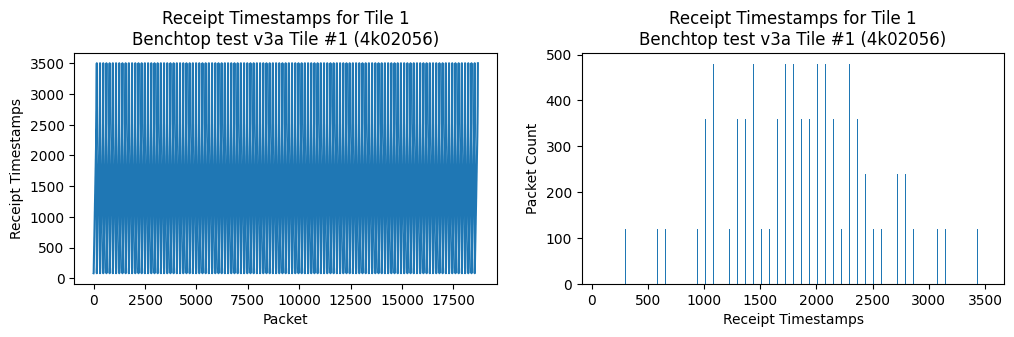

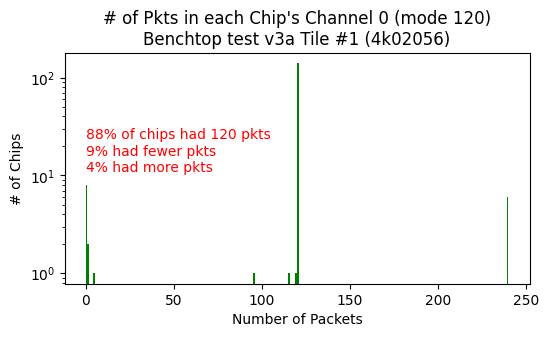

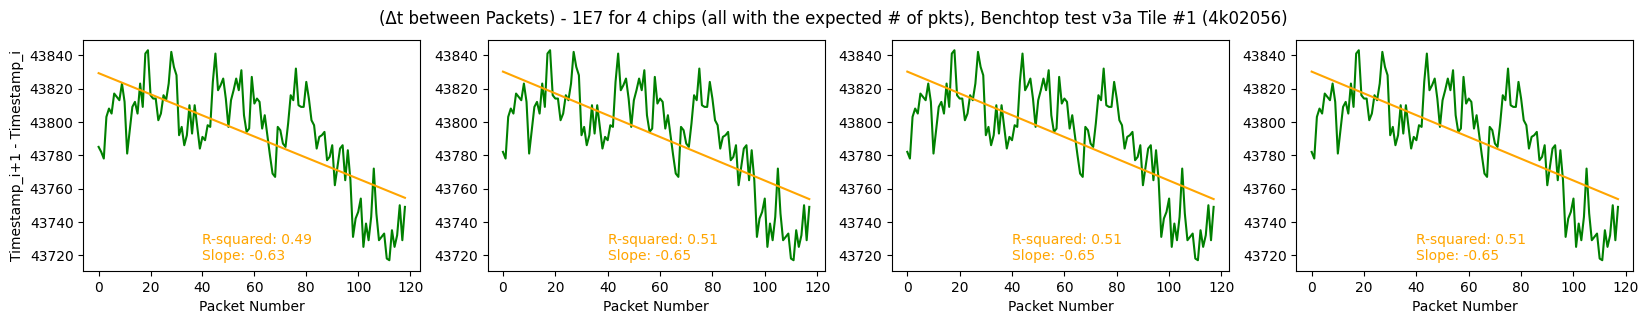

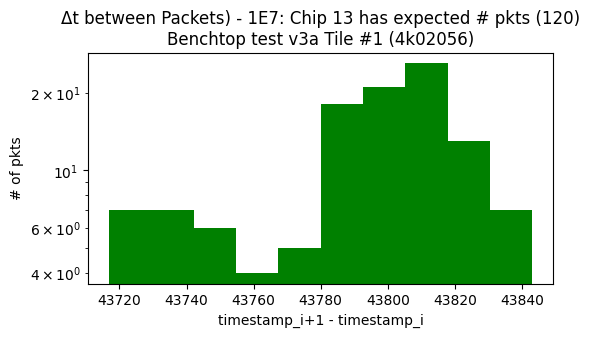

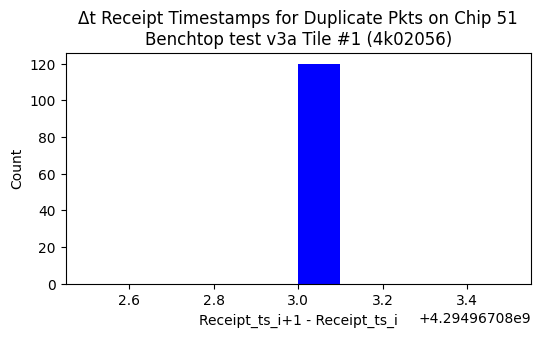

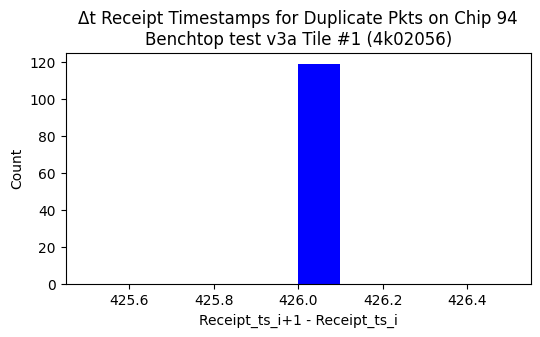

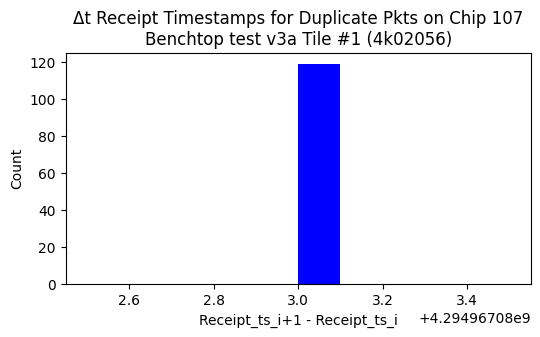

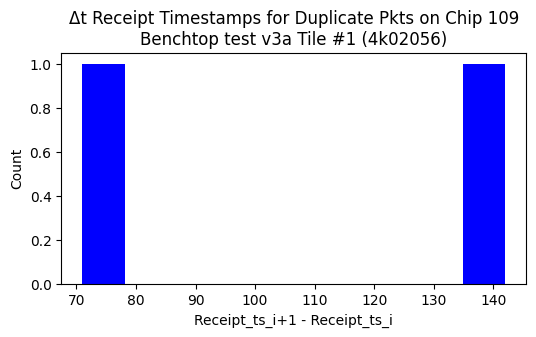

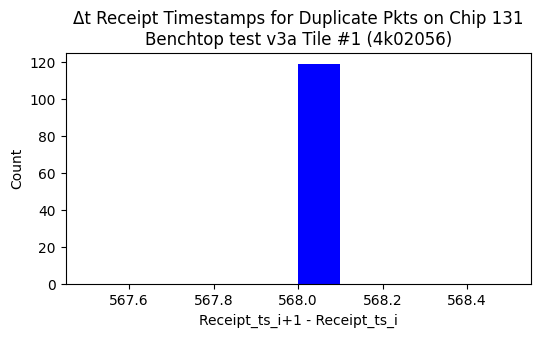

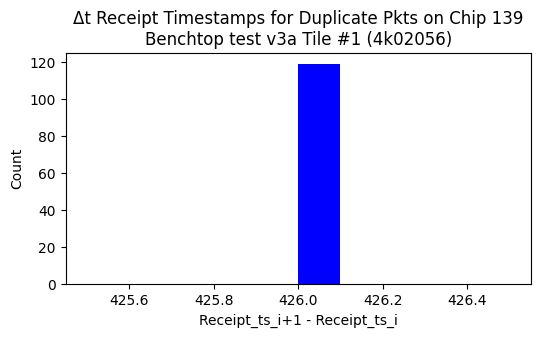

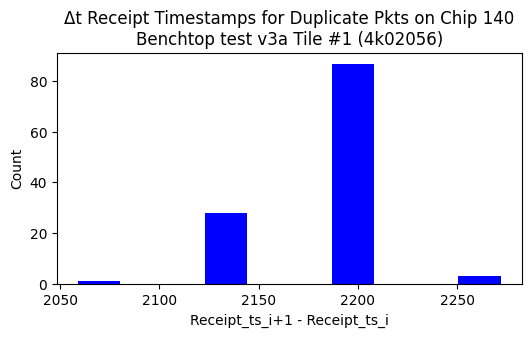

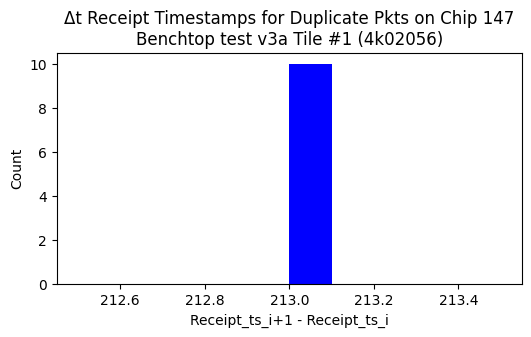

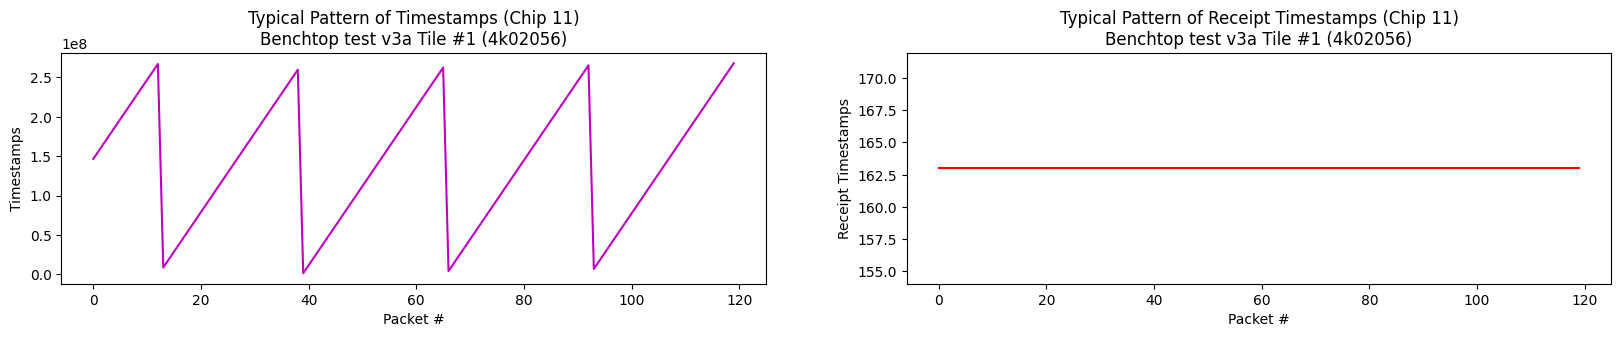

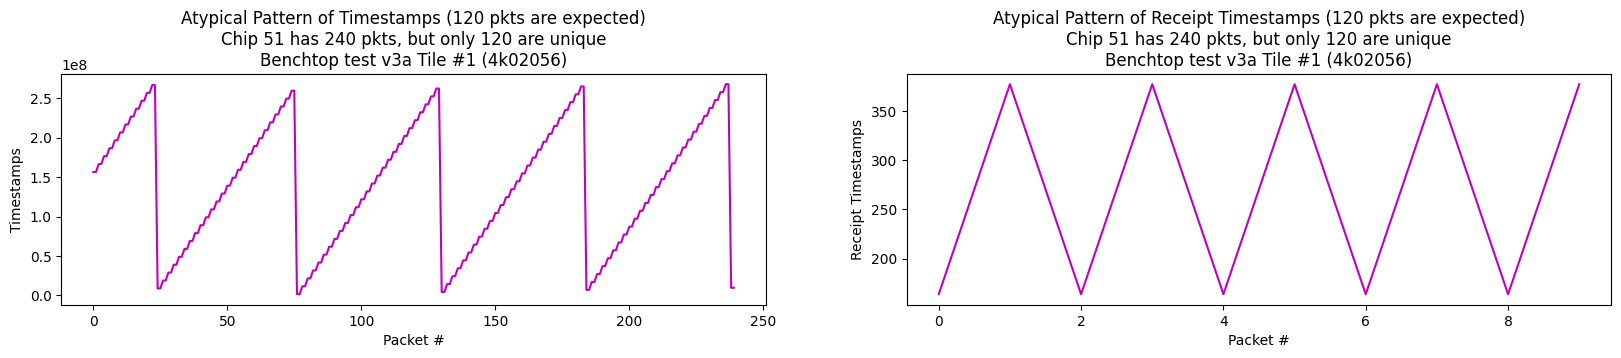

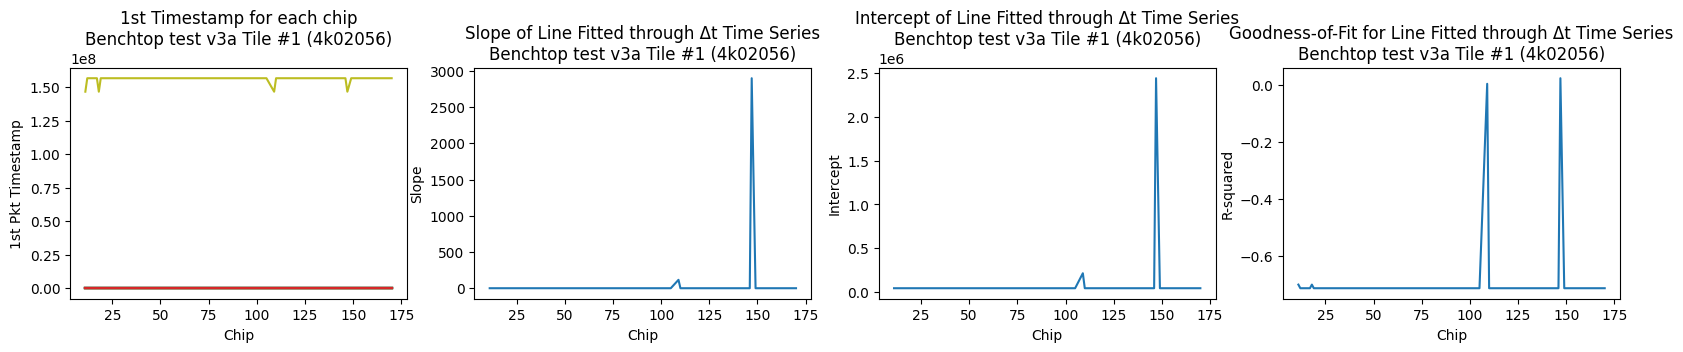

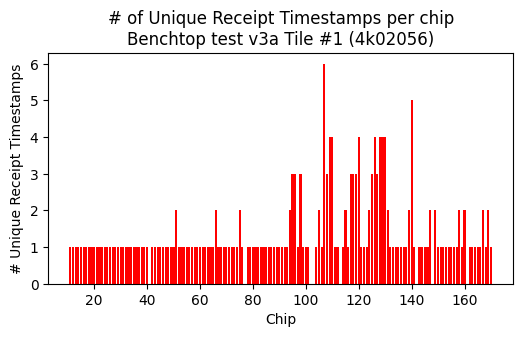

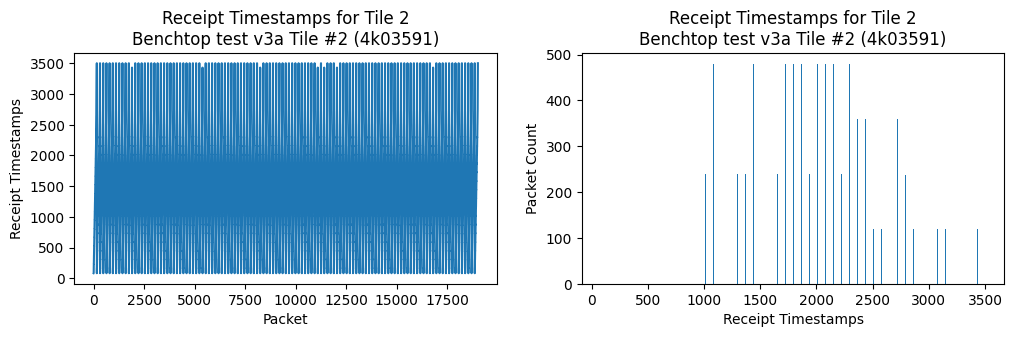

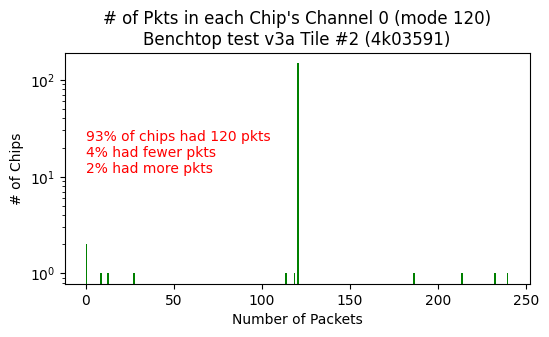

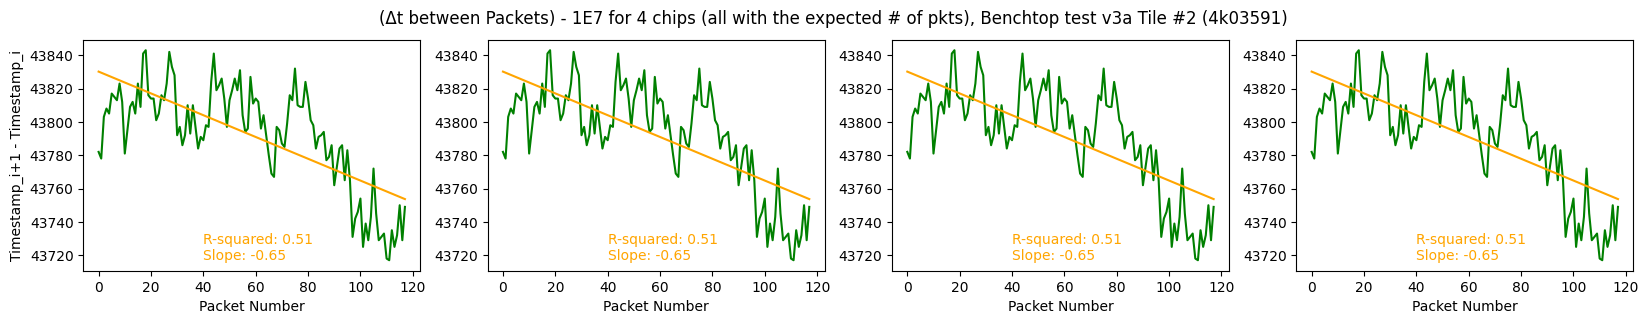

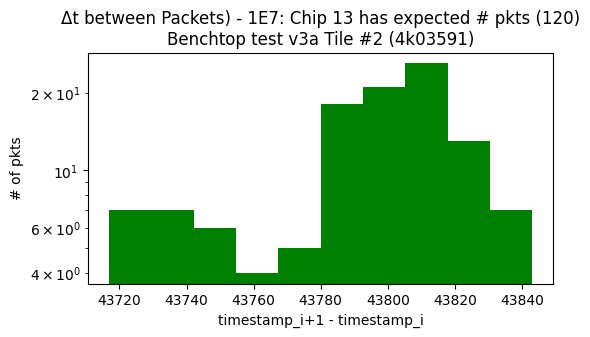

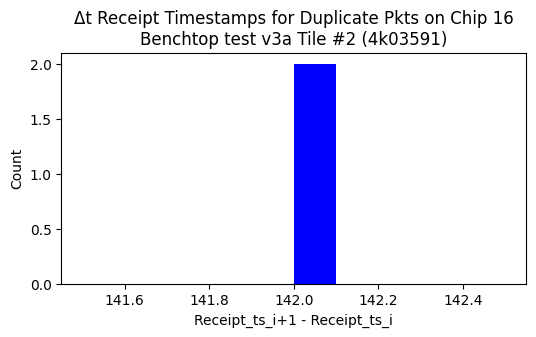

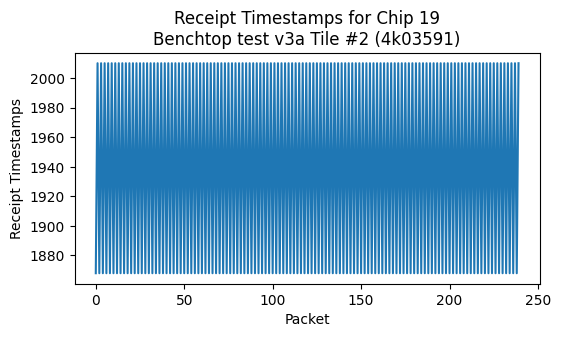

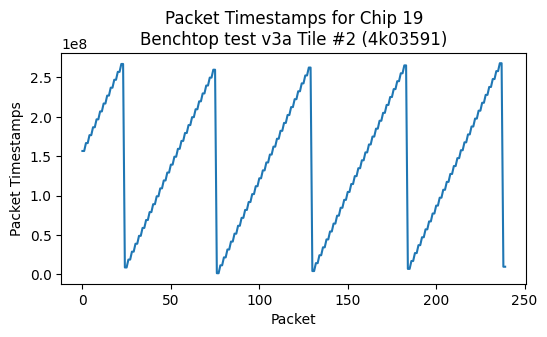

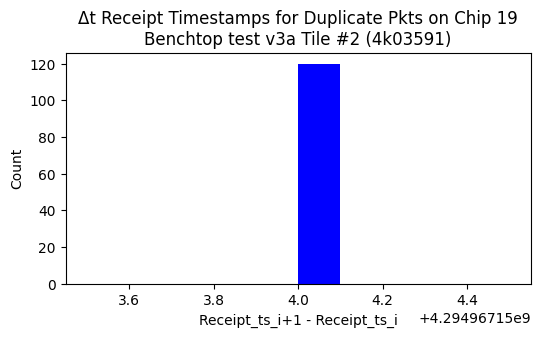

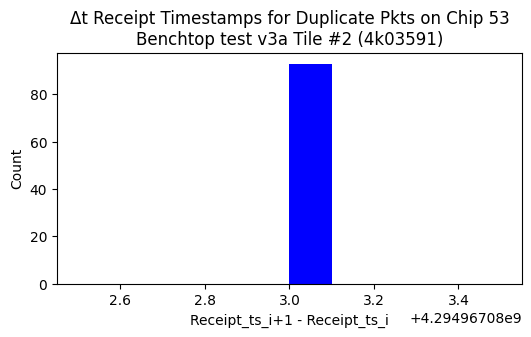

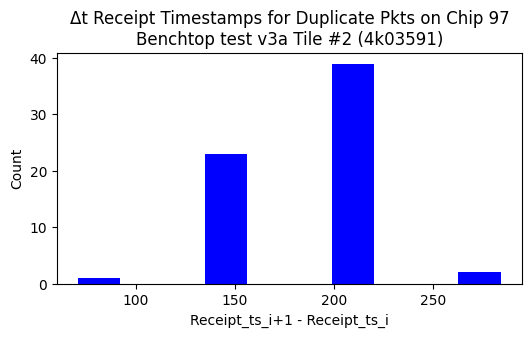

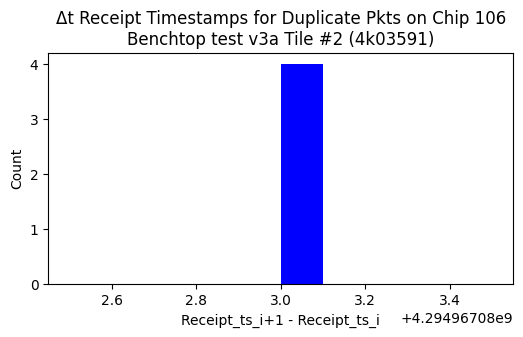

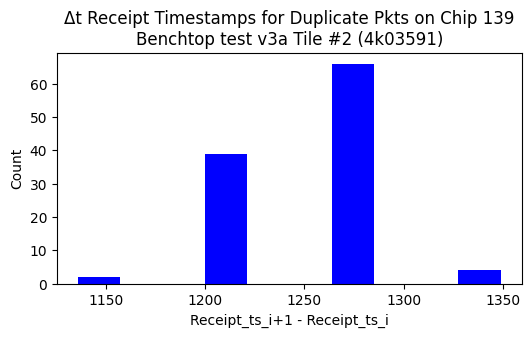

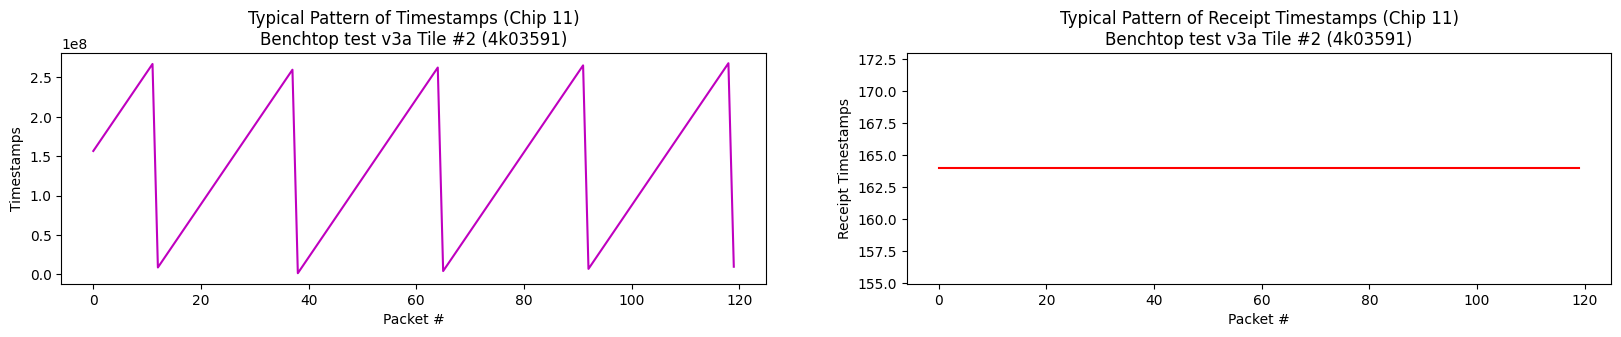

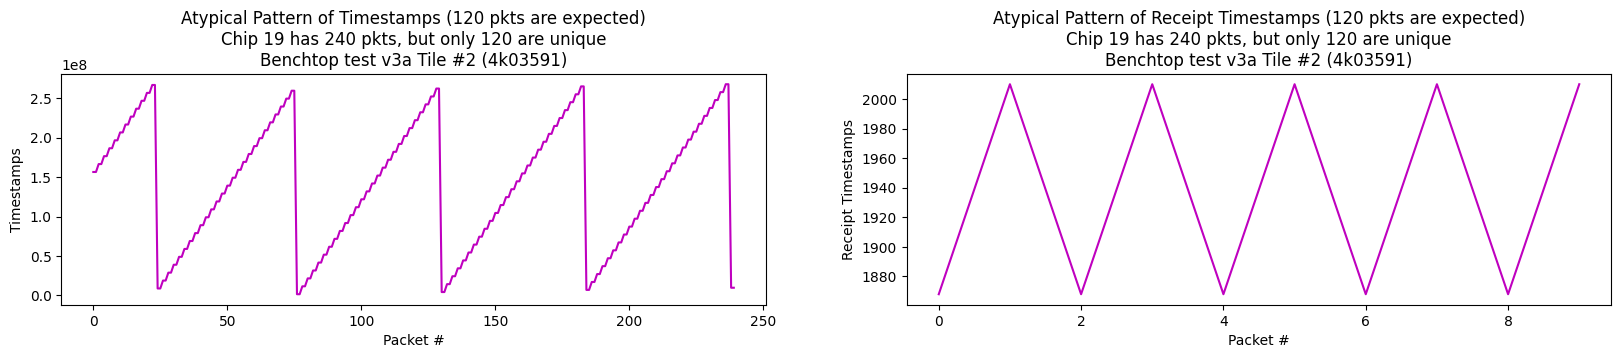

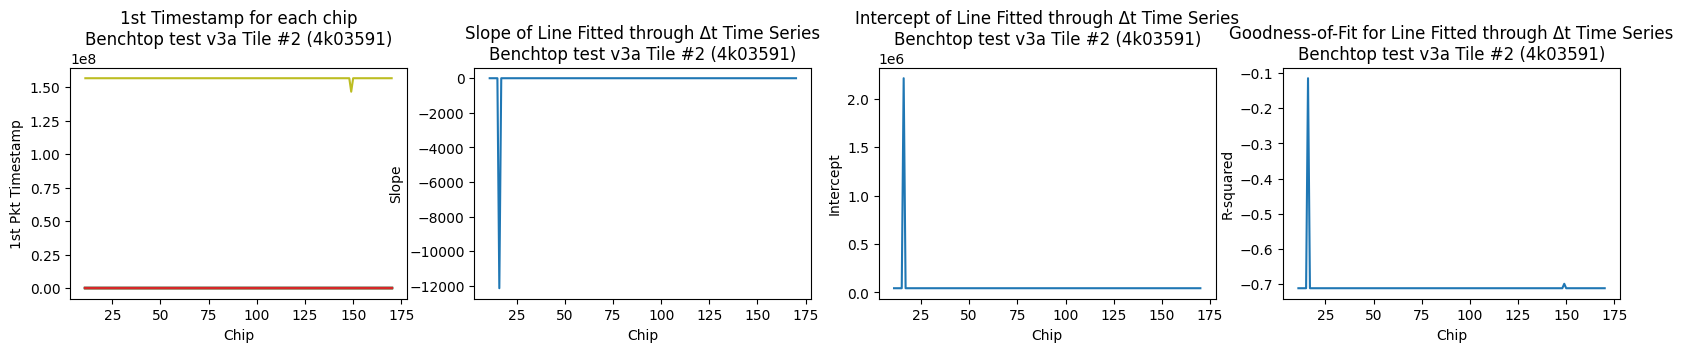

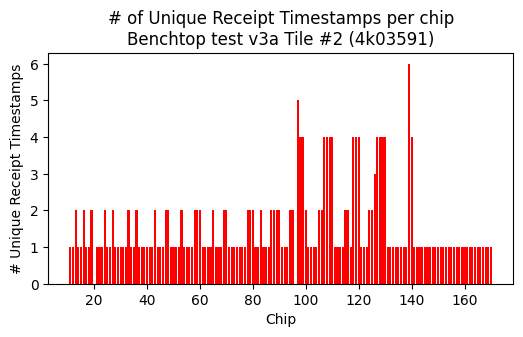

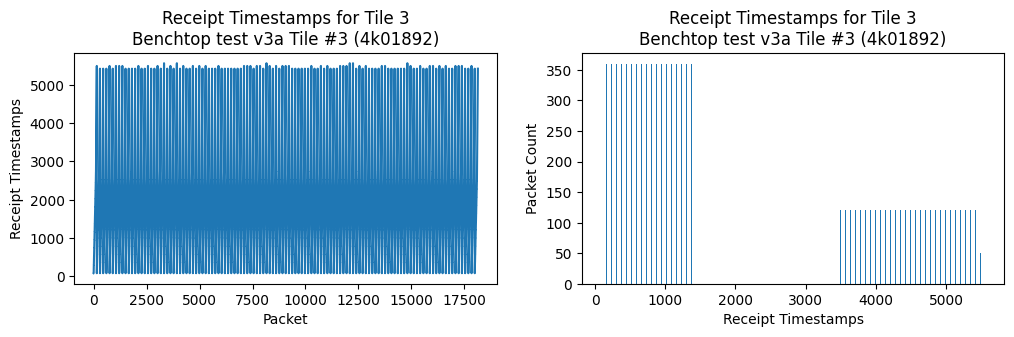

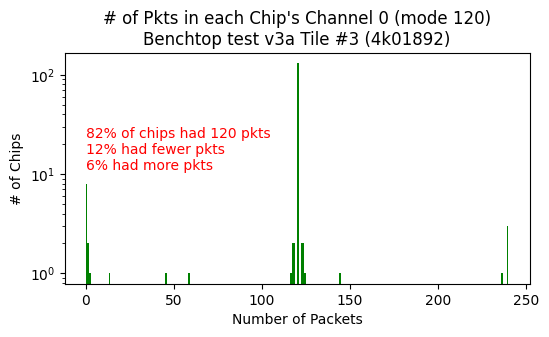

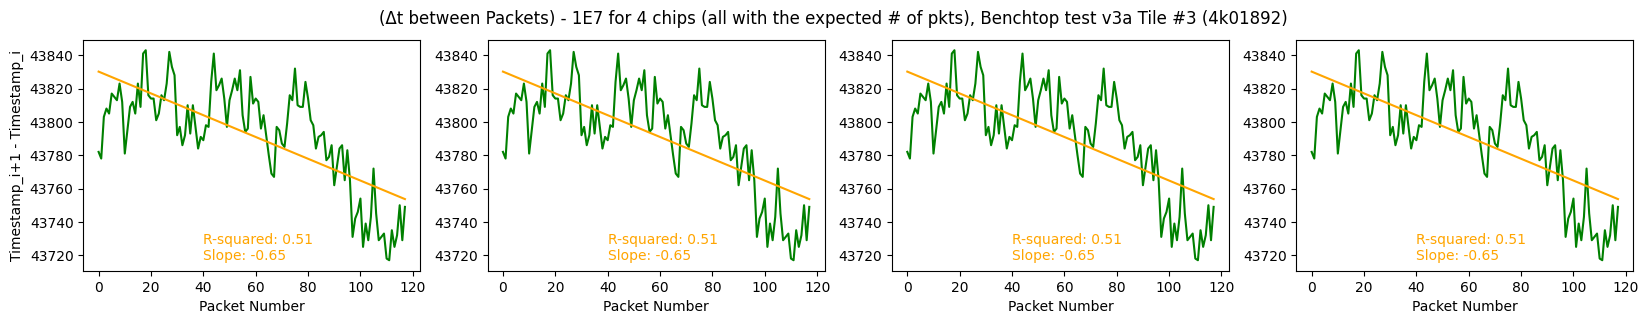

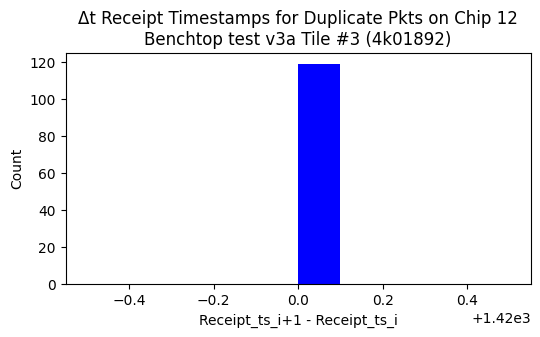

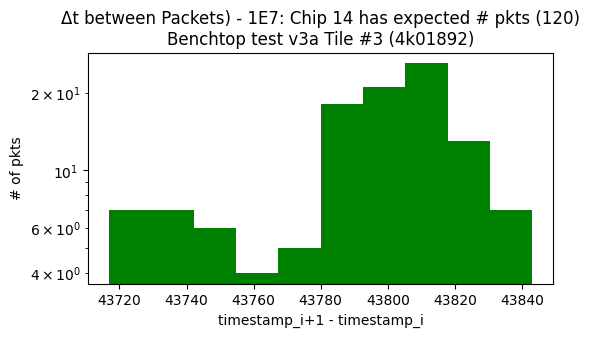

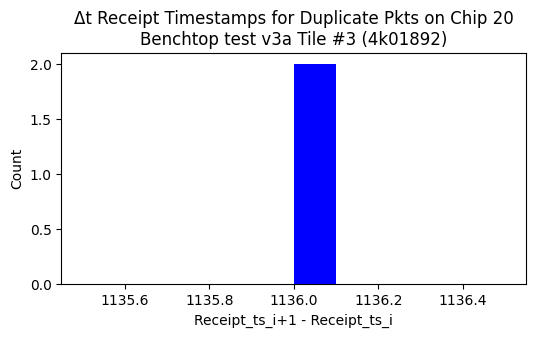

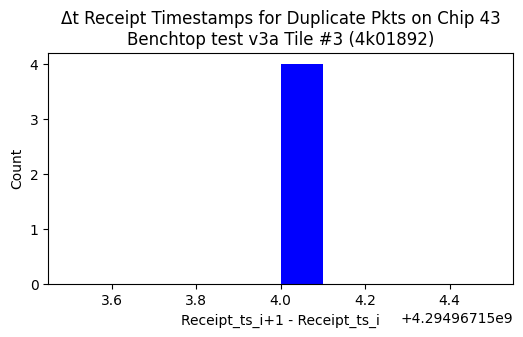

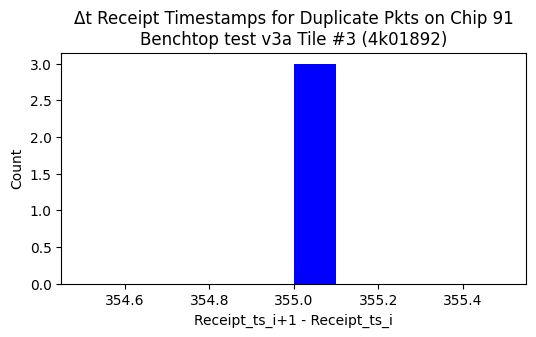

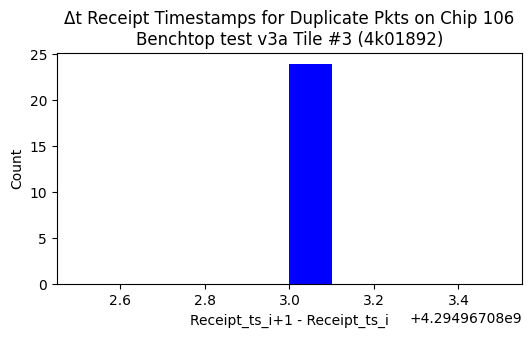

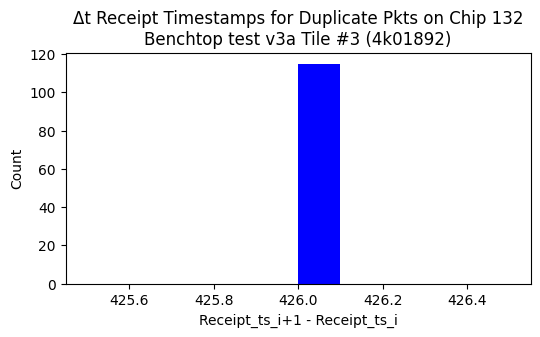

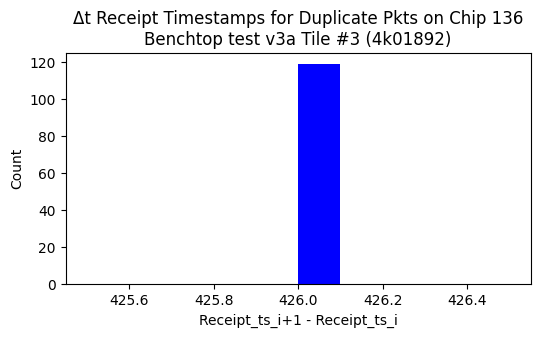

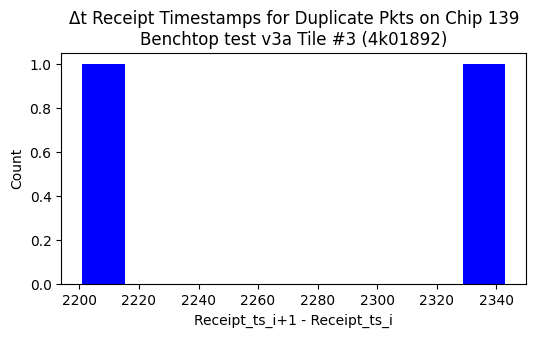

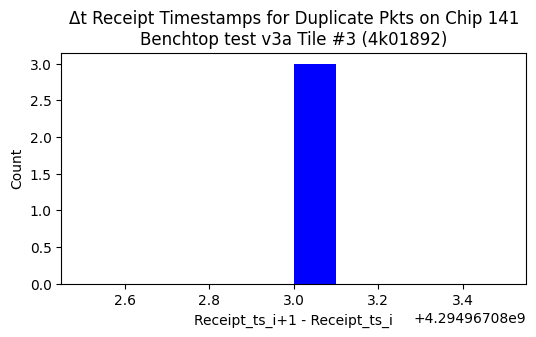

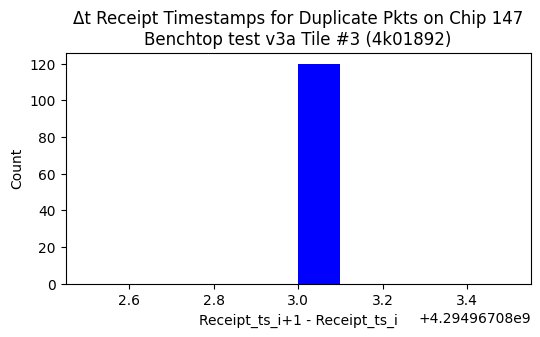

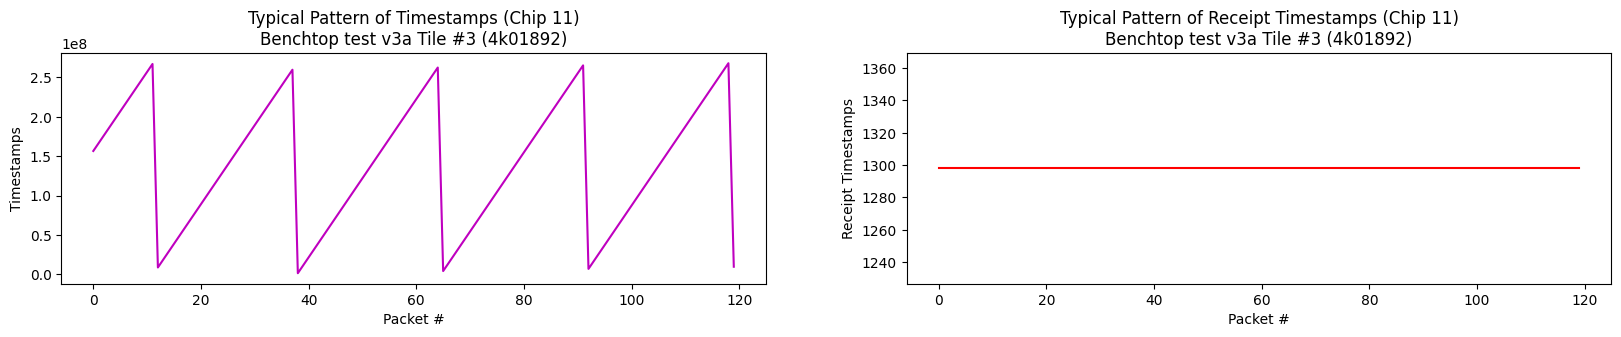

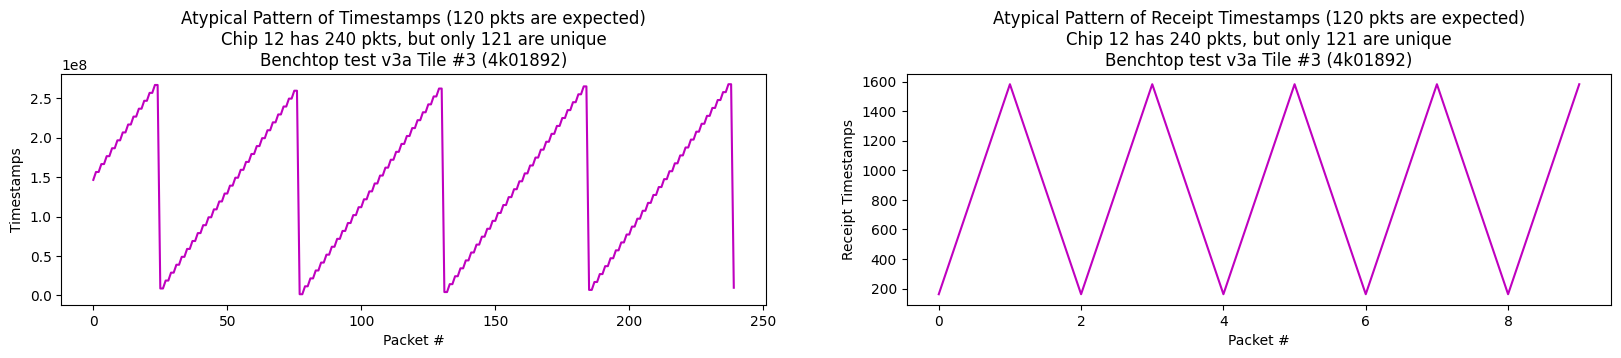

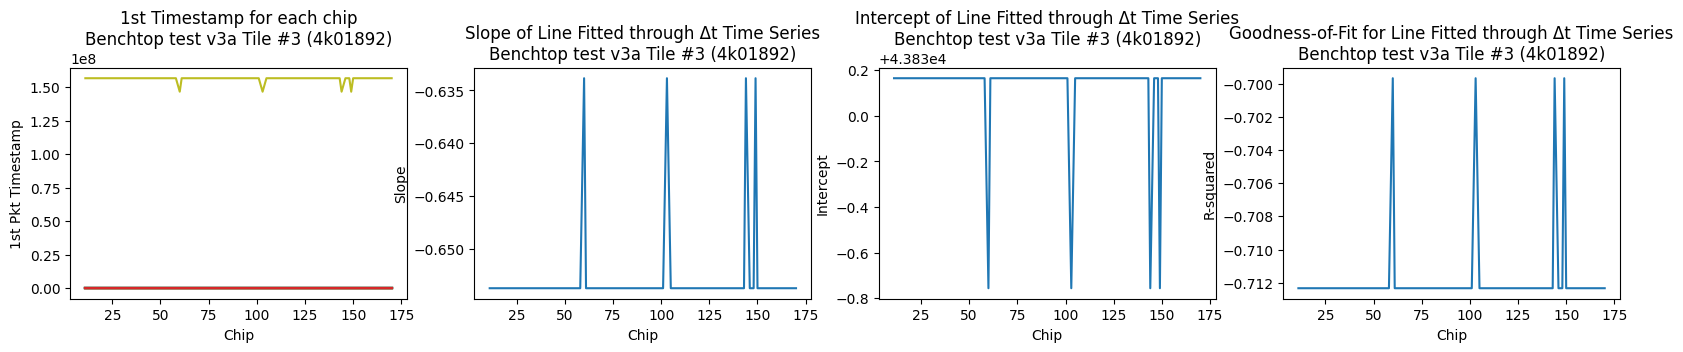

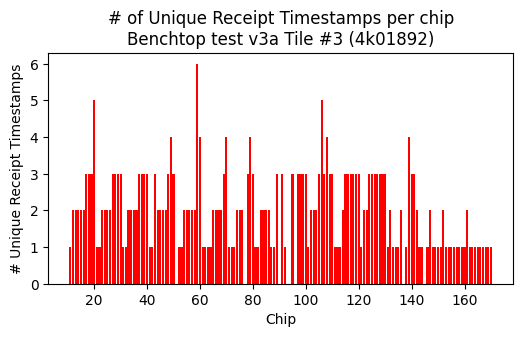

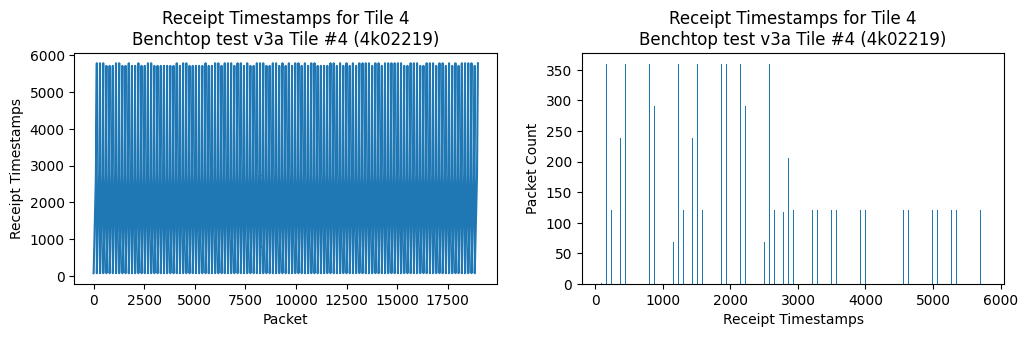

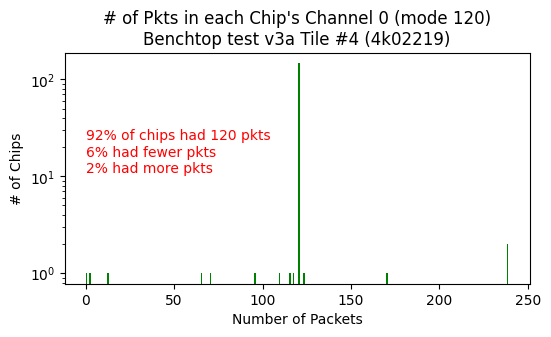

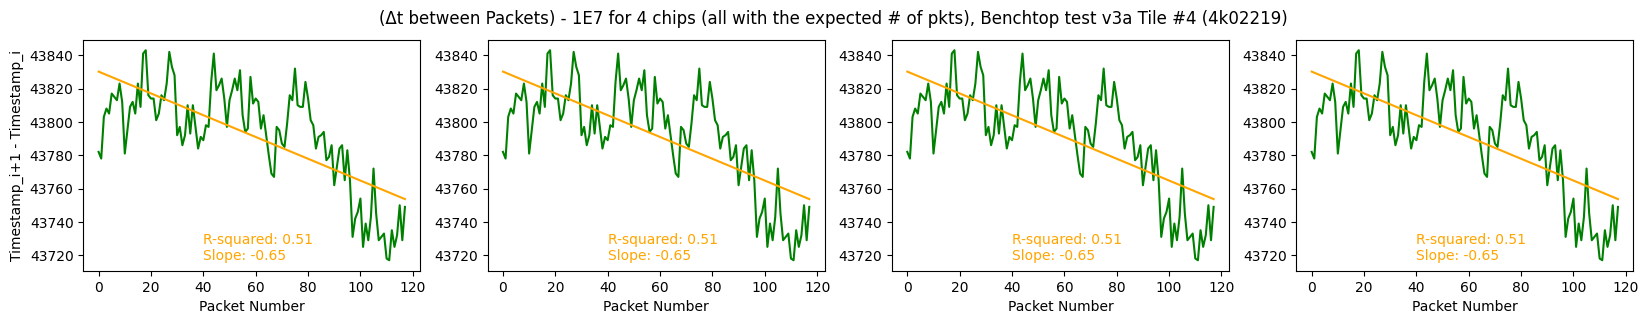

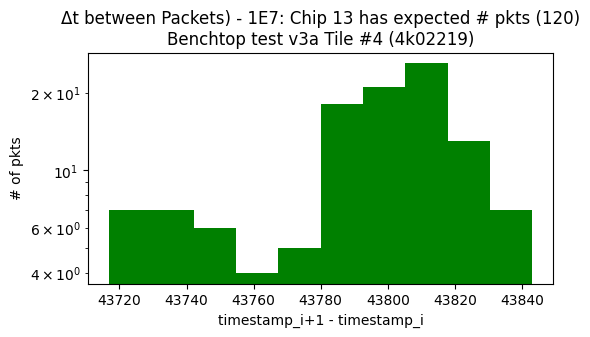

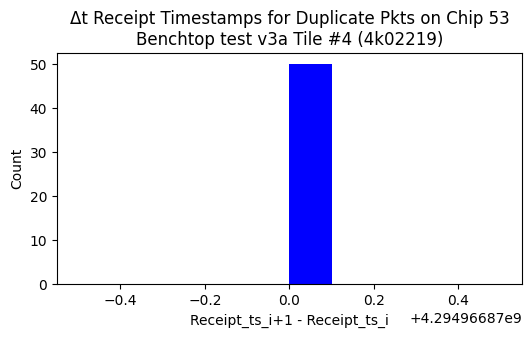

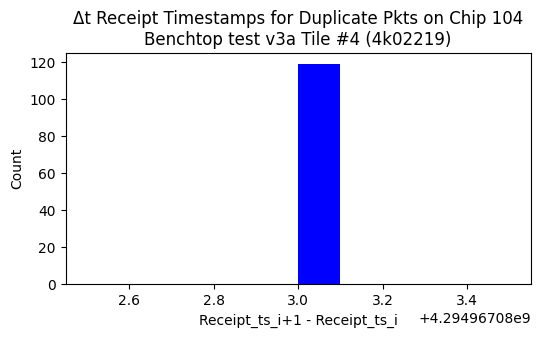

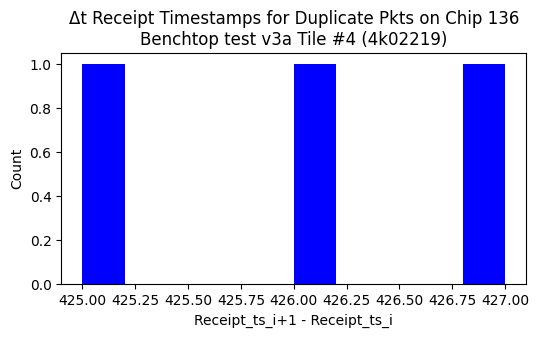

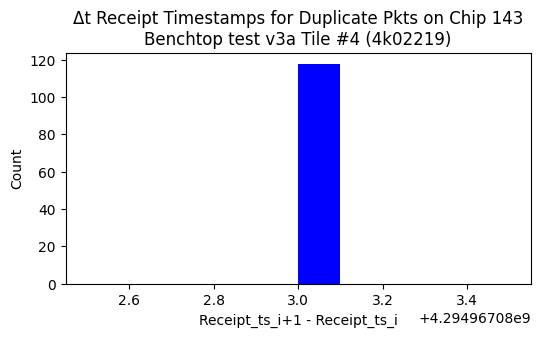

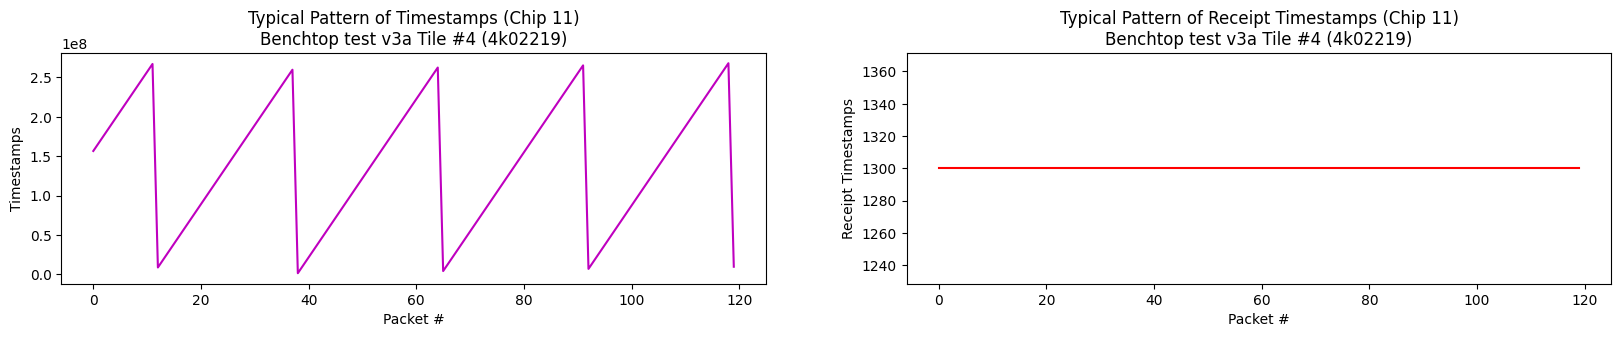

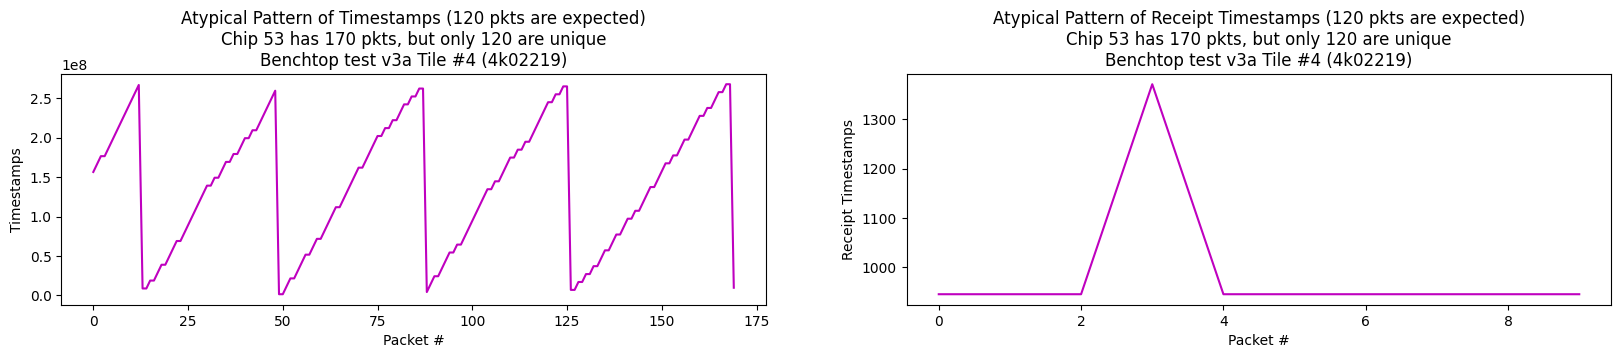

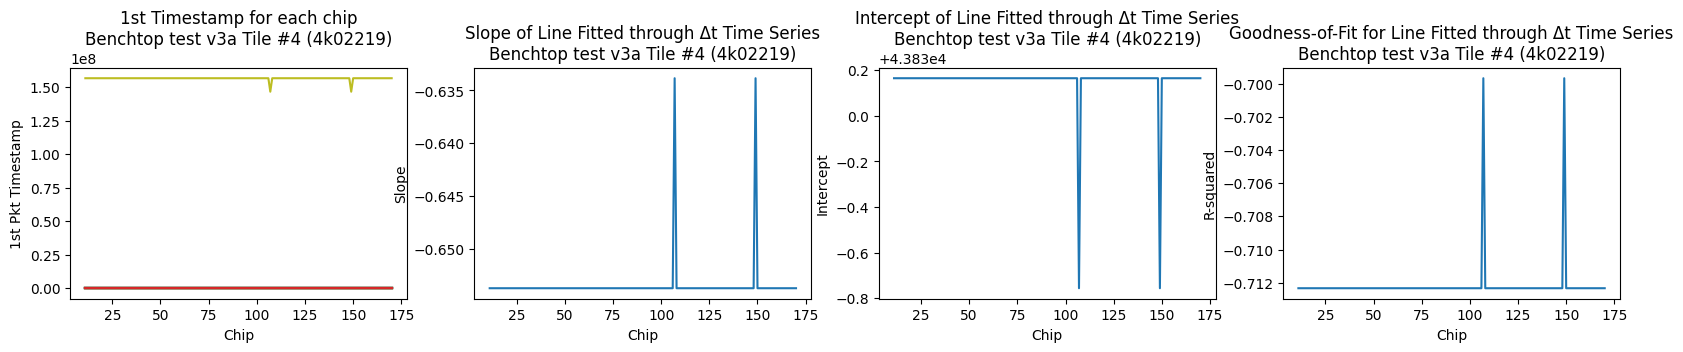

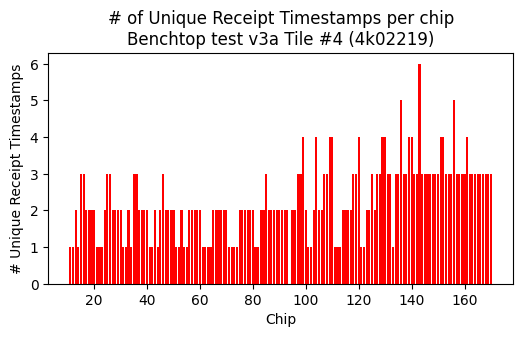

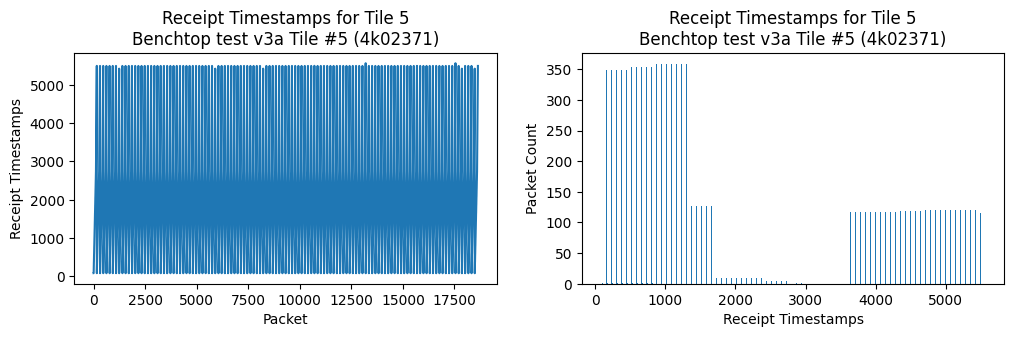

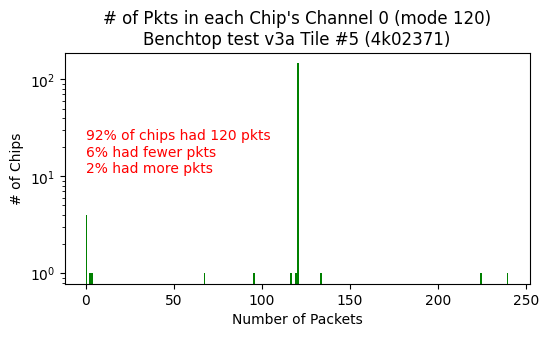

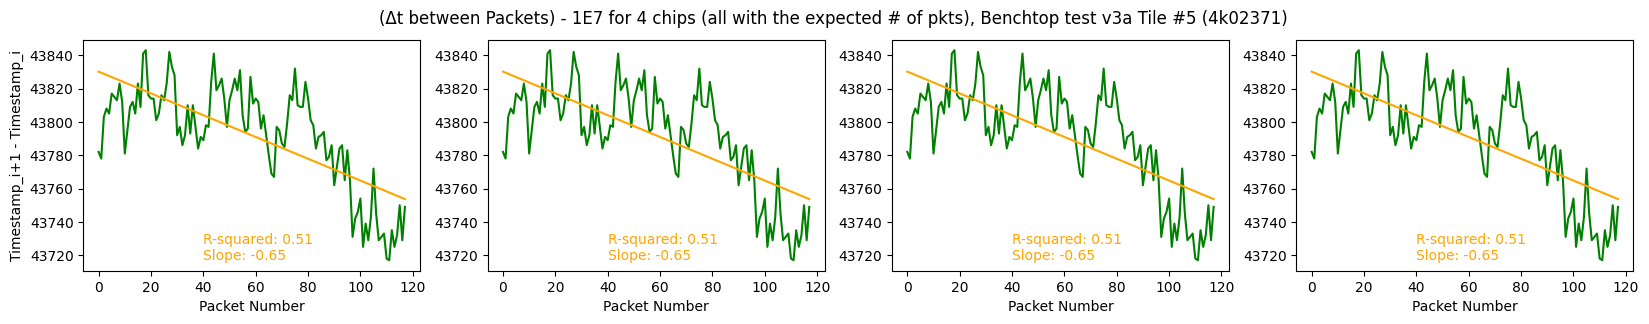

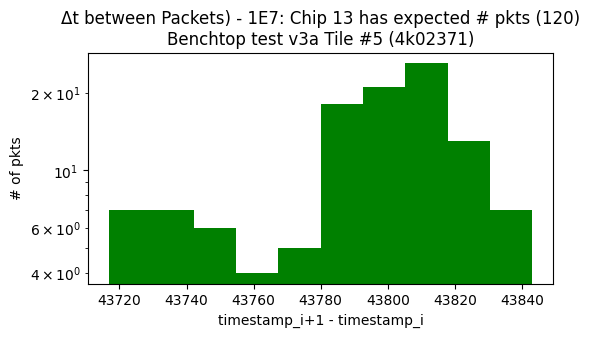

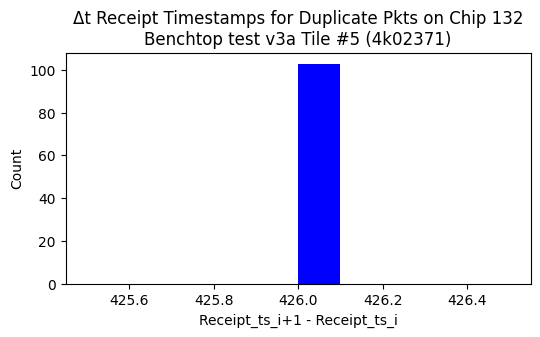

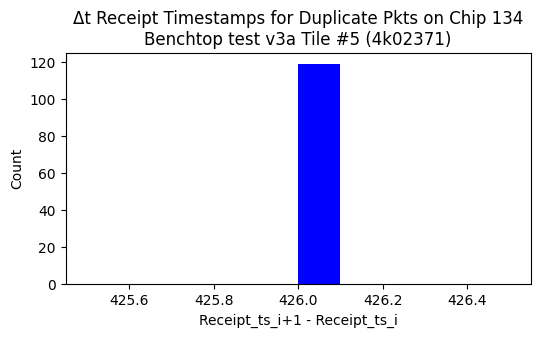

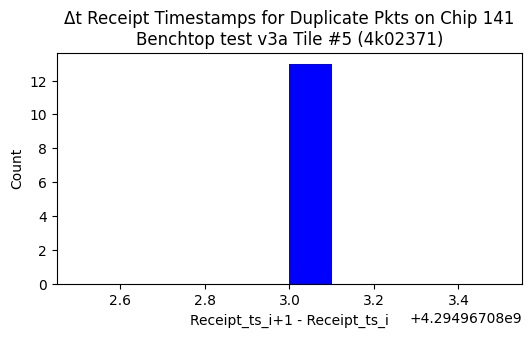

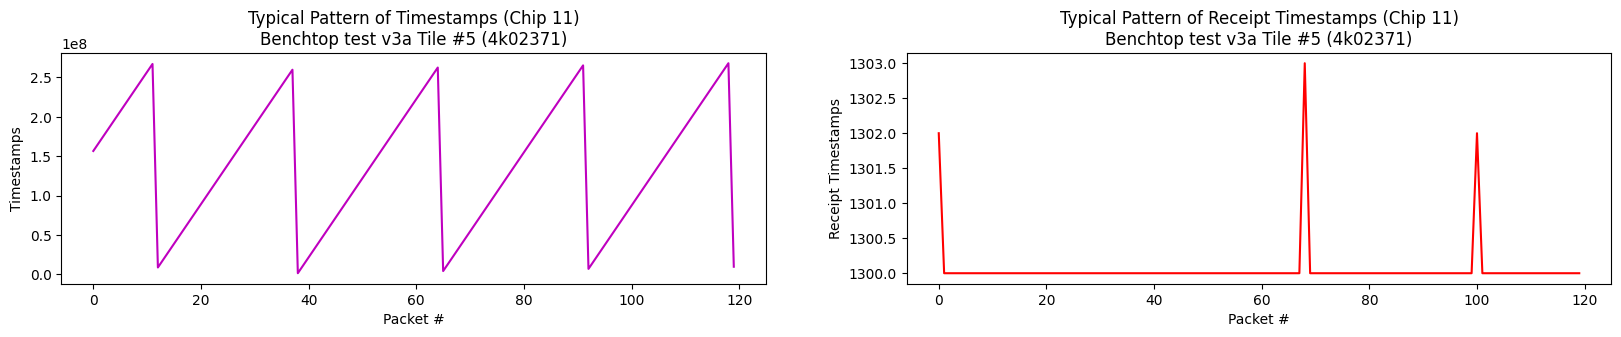

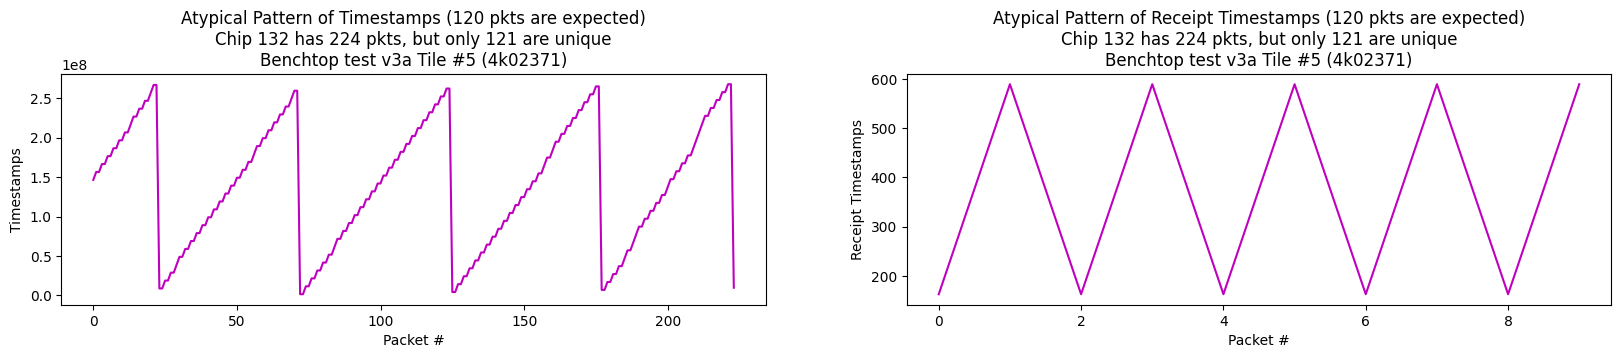

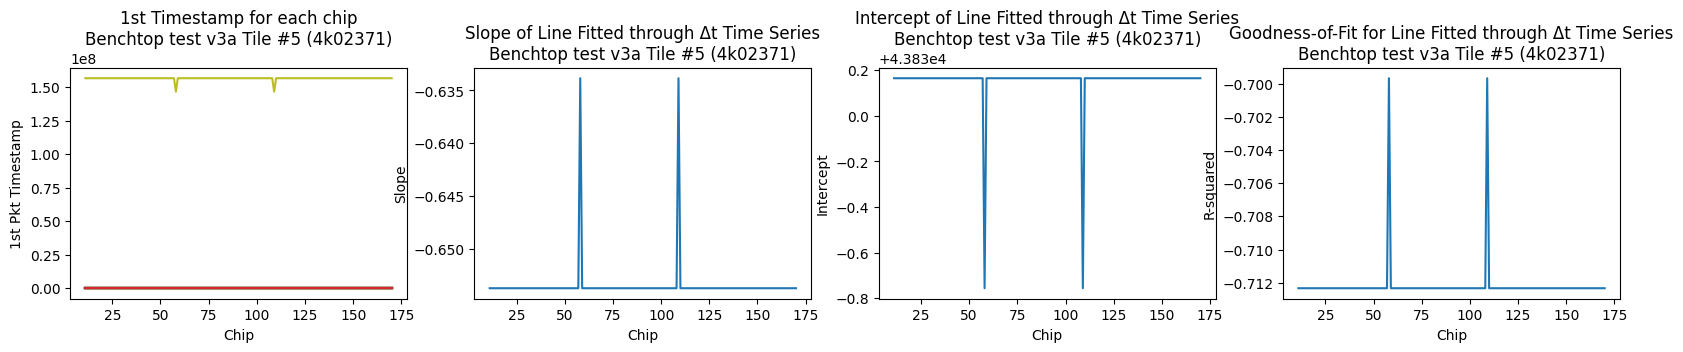

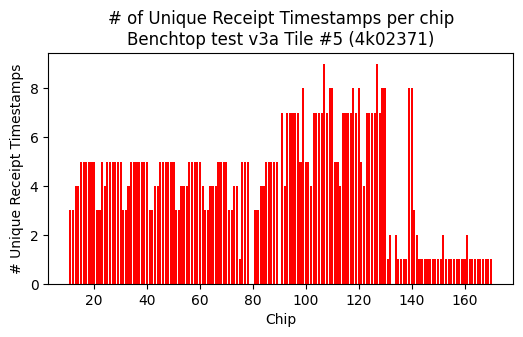

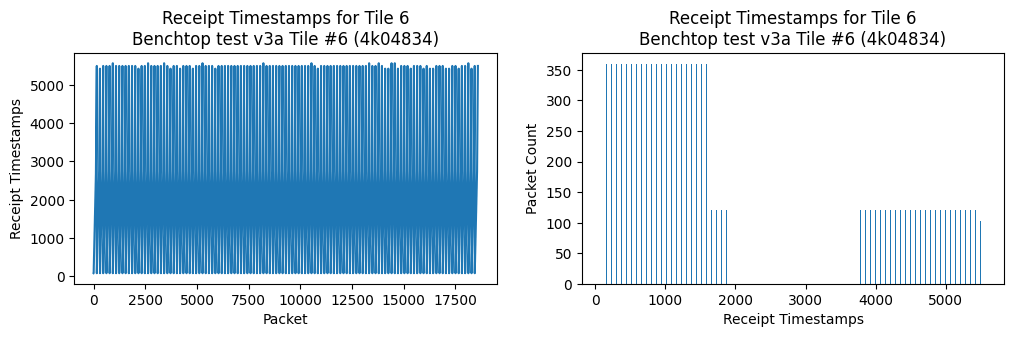

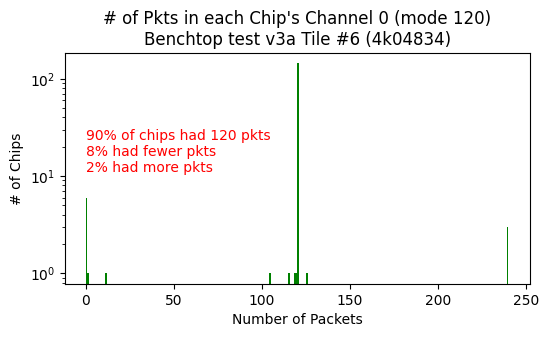

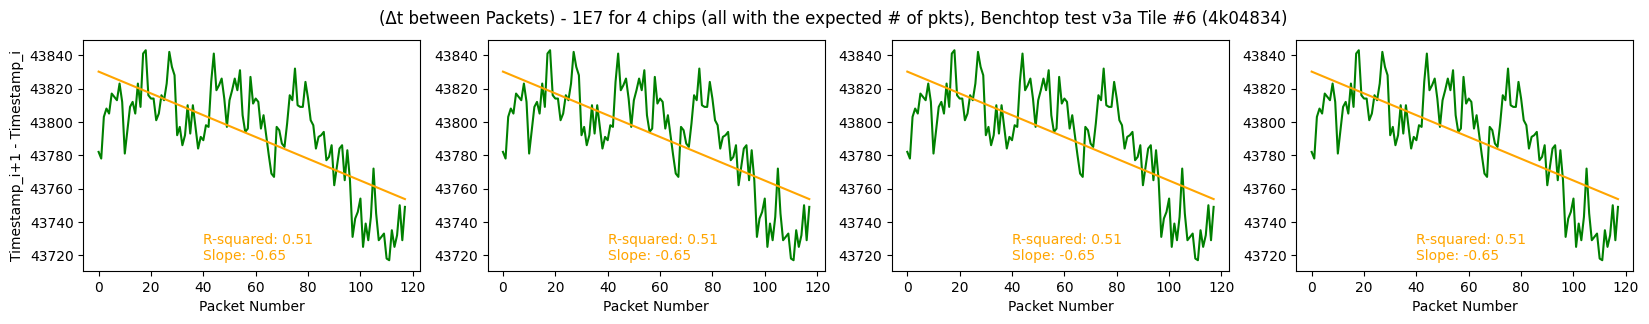

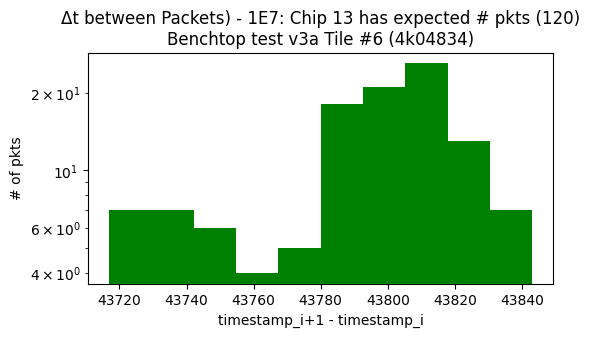

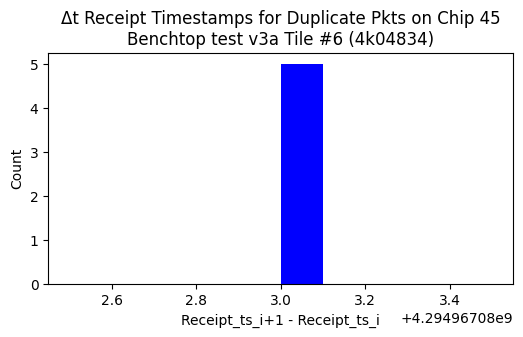

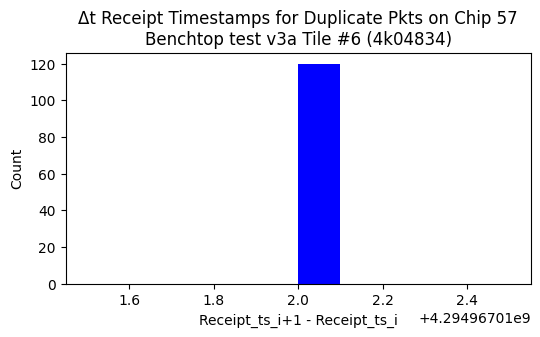

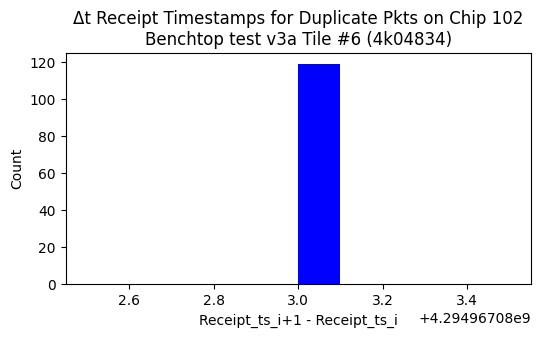

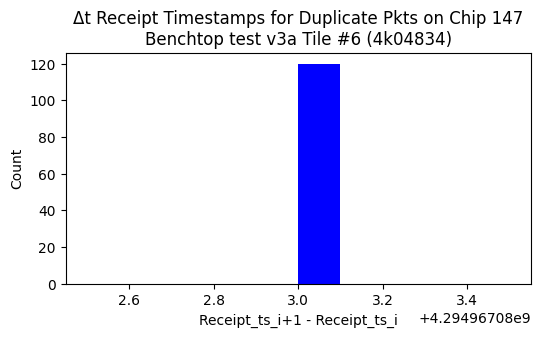

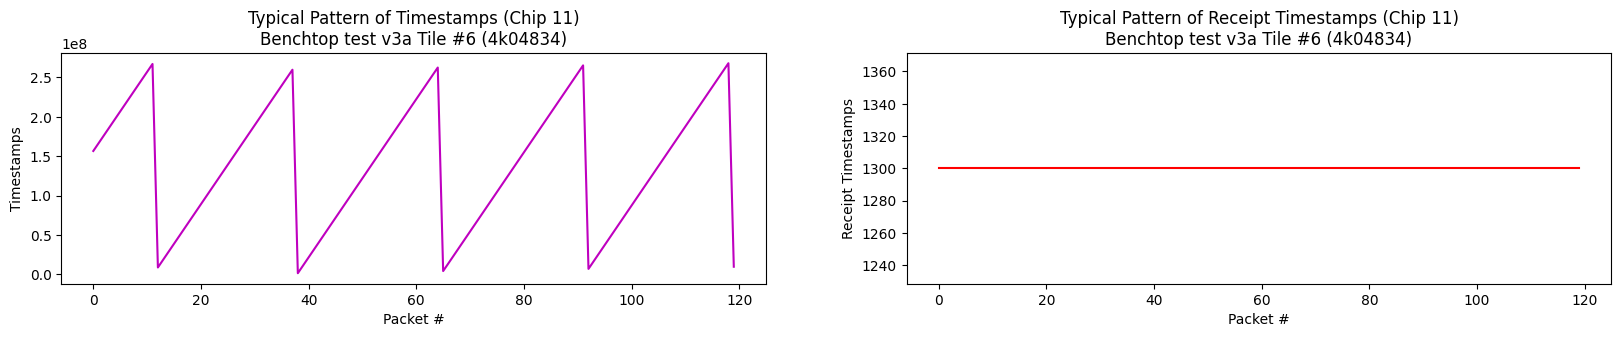

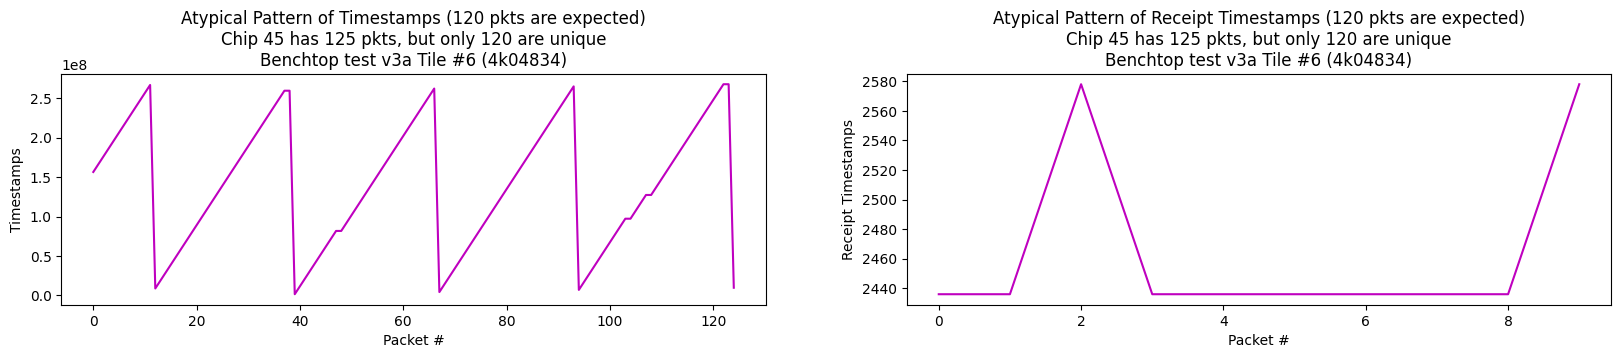

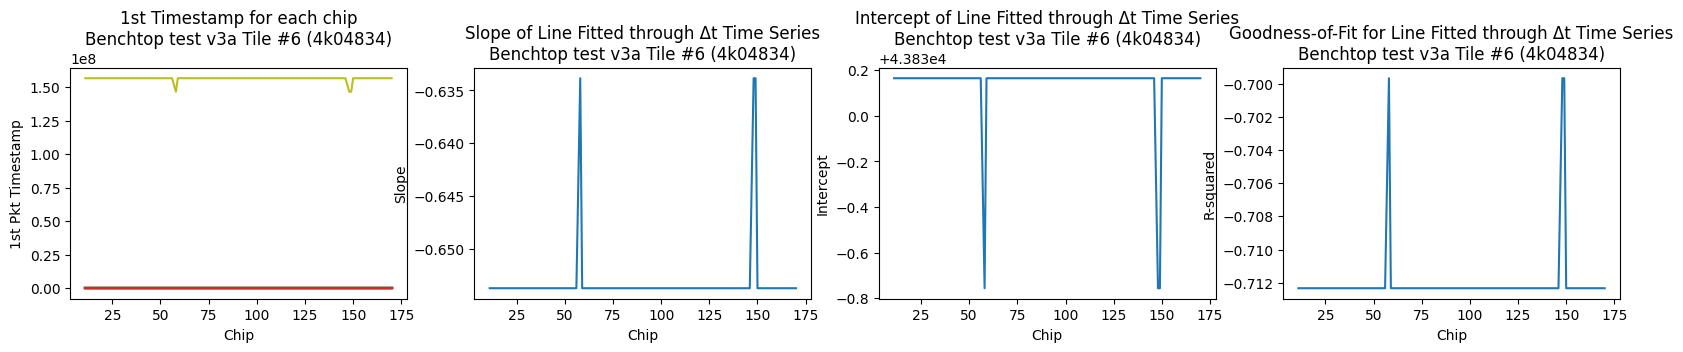

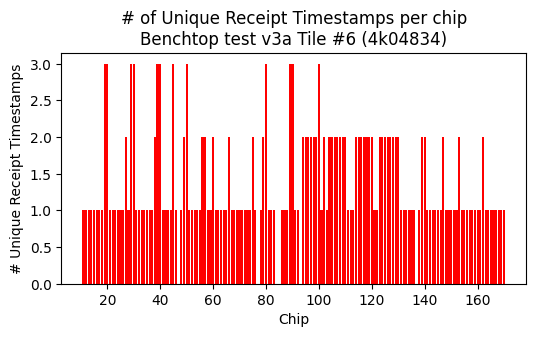

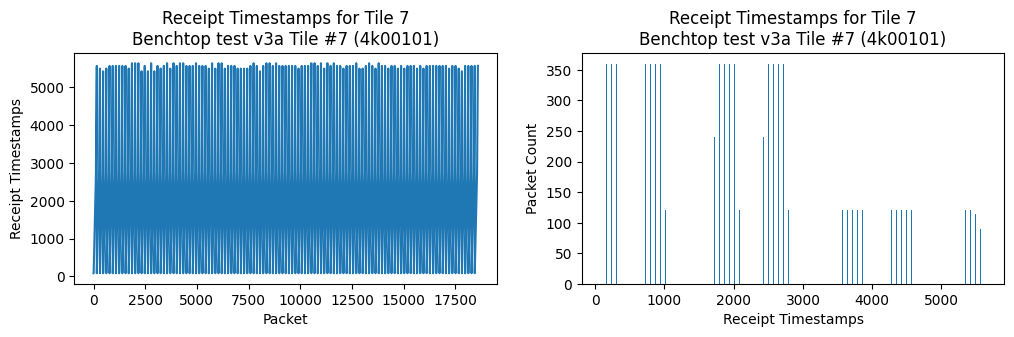

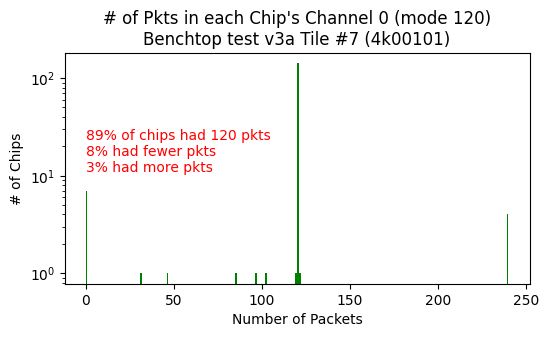

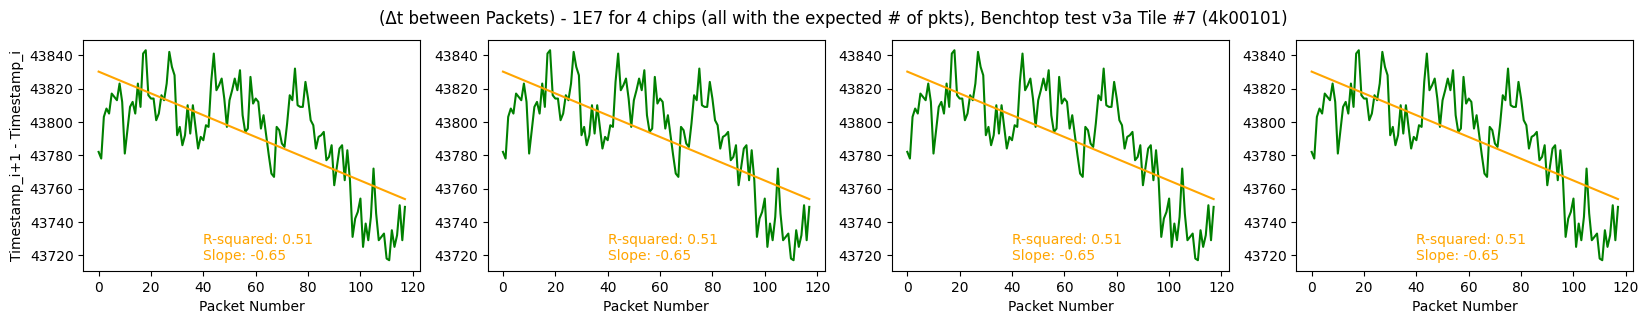

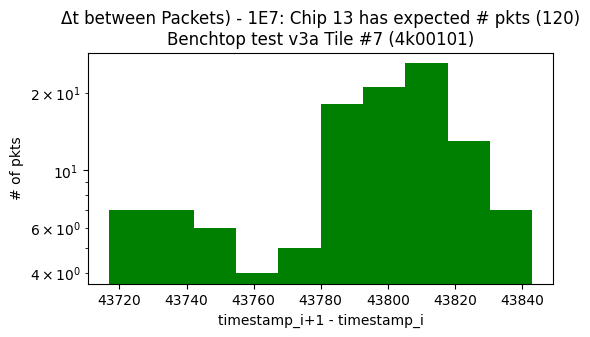

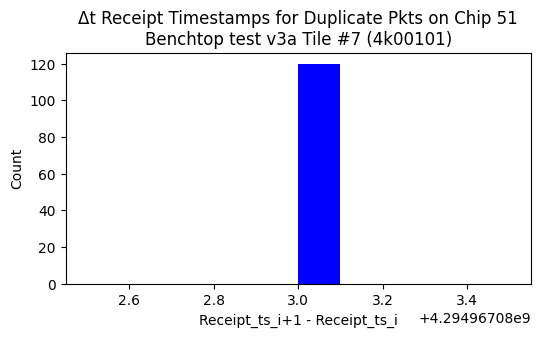

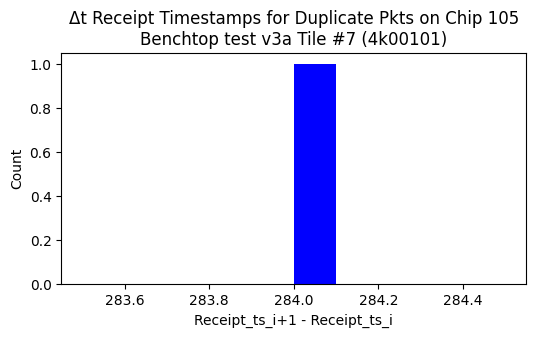

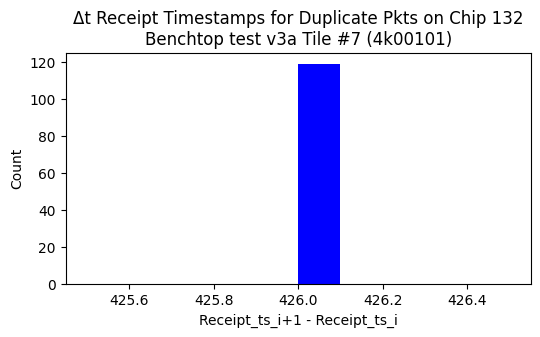

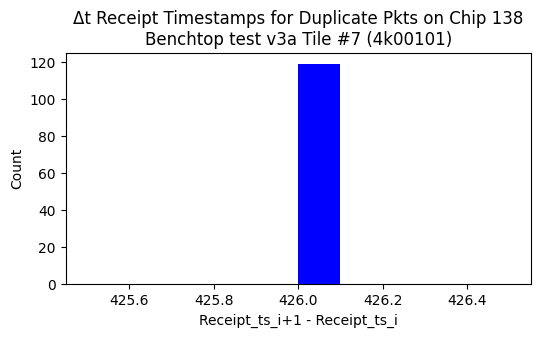

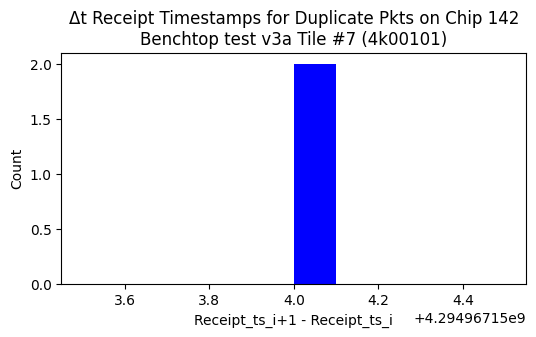

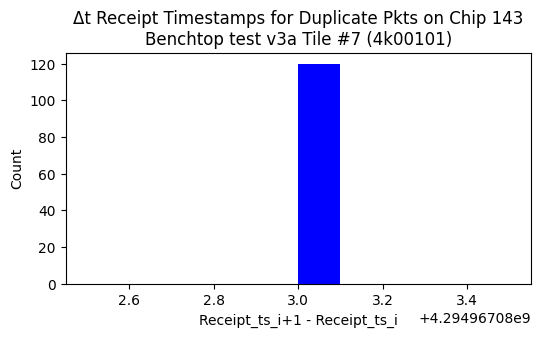

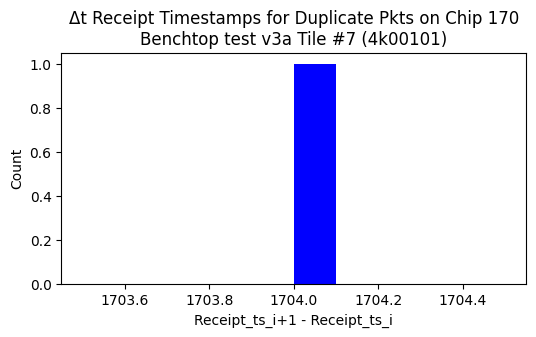

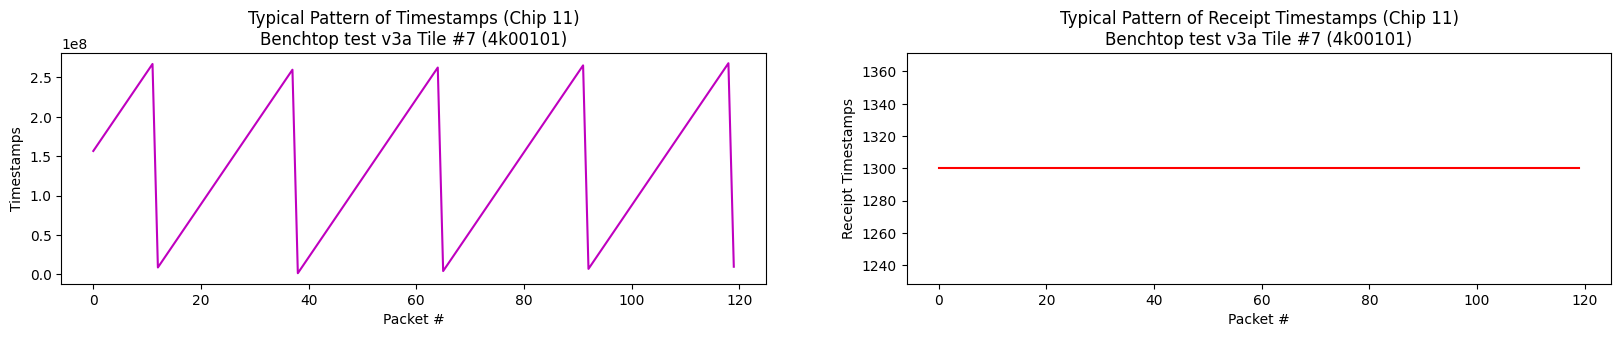

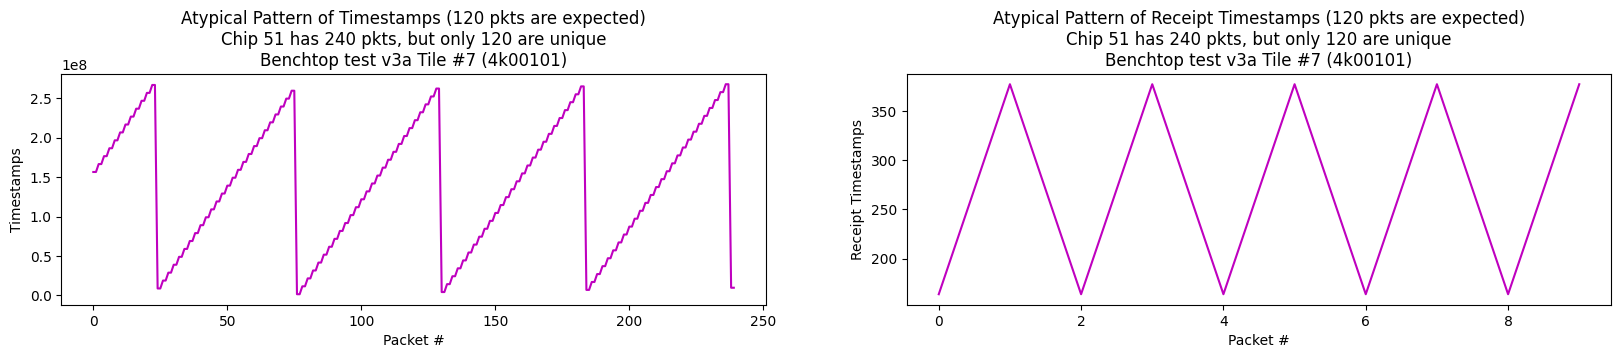

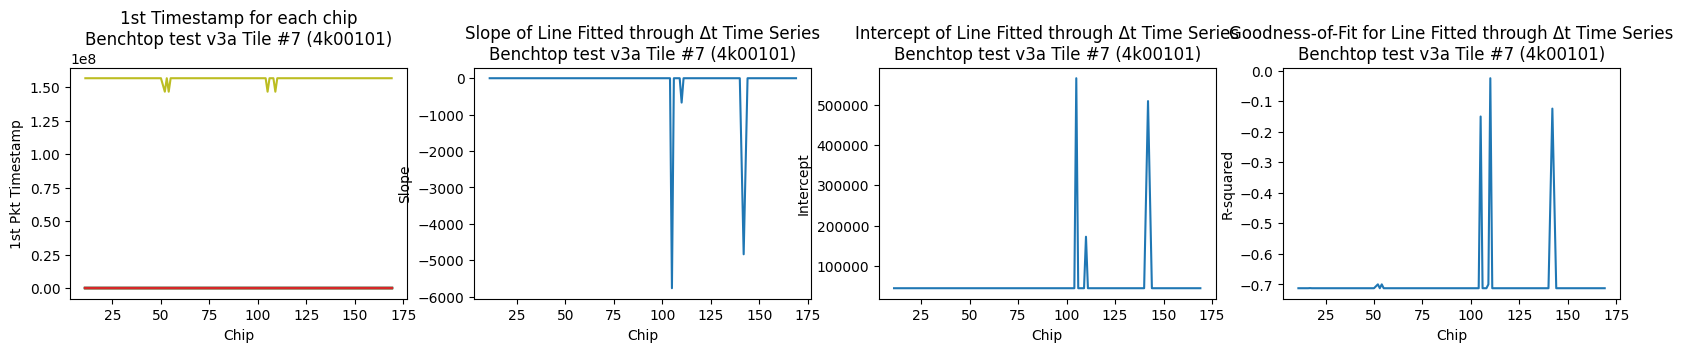

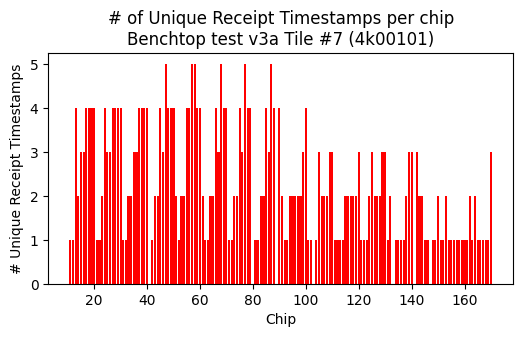

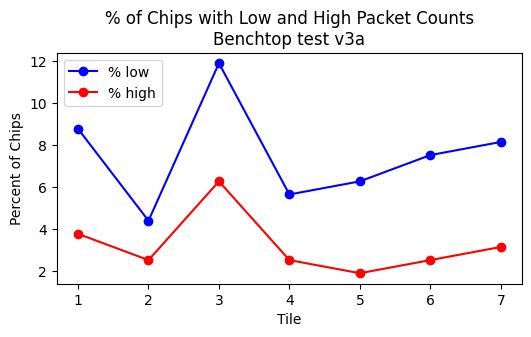

In [6]:
####################
# main
####################

print(f'Run Statistics for Data File {filename}:')

for tile in tiles:
    print(f"\n\n\n########################### Run Statistics Tile {tile} ###############################")
    
    get_timestamps(filename, tile, chip_serial_number_list[tile])

# graph % of chips that had low and high counts for each tile
fig, ax = plt.subplots(1,1, figsize=(6, 3))
ax.plot(tile_list, percent_low_list , label="% low", color = 'b', marker='o')
ax.plot(tile_list, percent_high_list, label="% high", color = 'r', marker='o')
ax.legend(loc="upper left")
ax.set_title(f"% of Chips with Low and High Packet Counts\nBenchtop test v3a")
ax.set_xlabel("Tile")
ax.set_ylabel("Percent of Chips")
